In [2]:
library(edgeR)
library(ggplot2)
library(ggrepel)
library(reshape2)
library(scales)
library(gridExtra)
library(biomaRt)
library(patchwork)
#library(ComplexHeatmap)
library(circlize)
#library(ChIPseeker)
library(dplyr)
library(ggrastr)
library(GenomicRanges)

In [3]:
saf_to_granges <- function(saf){
   library(GenomicRanges)
   gr <- with(saf, GRanges(Chr, IRanges(Start, End), id=Geneid, strand=Strand))
   return(gr)
}

## Read in data

In [4]:
wiz.data = read.table("../results//wiz_featurecounts.txt", header=1)
wiz.peak.info = wiz.data[,1:6]
wiz.data = wiz.data[,7:dim(wiz.data)[2]]
rownames(wiz.data) = wiz.peak.info$Geneid
colnames(wiz.data) = gsub("...bowtie2_bam.", "", 
                   gsub("_aligned_sorted_noblacklist.bam", "", colnames(wiz.data)))
head(wiz.data)

,clone32__HU__G9a__rep1,clone32__HU__G9a__rep2,clone32__HU__G9a__rep3,clone32__Unt__G9a__rep1,clone32__Unt__G9a__rep2,clone32__Unt__G9a__rep3,clone32__HU__WIZ__rep1,clone32__HU__WIZ__rep2,clone32__HU__WIZ__rep3,clone32__Unt__WIZ__rep1,⋯,clone32__HU__H3K27ac__rep2,clone32__HU__H3K27ac__rep3,clone32__Unt__H3K27ac__rep1,clone32__Unt__H3K27ac__rep2,clone32__Unt__H3K27ac__rep3,clone32__HU__H3K27me3__rep2,clone32__HU__H3K27me3__rep3,clone32__Unt__H3K27me3__rep1,clone32__Unt__H3K27me3__rep2,clone32__Unt__H3K27me3__rep3
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
wiz_peak1,16,11,9,8.0,7,4,69,88,93,283.0,⋯,22,23,32.0,21,39,3,5,6.0,4.0,1
wiz_peak2,6,1,9,4.0,4,3,10,9,10,46.0,⋯,5,8,1.0,3,4,3,8,6.0,6.0,5
wiz_peak3,3,5,3,2.0,5,4,16,33,30,103.0,⋯,4,4,4.0,3,3,0,1,0.0,2.0,1
wiz_peak4,25,15,12,9.0,18,19,100,114,124,467.0,⋯,22,17,18.0,6,16,107,98,100.0,123.0,106
wiz_peak5,9,9,8,8.0,10,14,86,141,120,402.0,⋯,14,8,9.0,7,15,81,58,83.0,79.0,83
wiz_peak6,1,5,4,3.5,9,12,51,75,68,260.5,⋯,6,12,8.5,3,5,2,7,4.5,5.5,3


In [5]:
g9a.data = read.table("../results//g9a_featurecounts.txt", header=1)
g9a.peak.info = g9a.data[,1:6]
g9a.data = g9a.data[,7:dim(g9a.data)[2]]
rownames(g9a.data) = g9a.peak.info$Geneid

colnames(g9a.data) = gsub("...bowtie2_bam.", "", 
                   gsub("_aligned_sorted_noblacklist.bam", "", colnames(g9a.data)))
head(g9a.data)

,clone32__HU__G9a__rep1,clone32__HU__G9a__rep2,clone32__HU__G9a__rep3,clone32__Unt__G9a__rep1,clone32__Unt__G9a__rep2,clone32__Unt__G9a__rep3,clone32__HU__WIZ__rep1,clone32__HU__WIZ__rep2,clone32__HU__WIZ__rep3,clone32__Unt__WIZ__rep1,⋯,clone32__HU__H3K27ac__rep2,clone32__HU__H3K27ac__rep3,clone32__Unt__H3K27ac__rep1,clone32__Unt__H3K27ac__rep2,clone32__Unt__H3K27ac__rep3,clone32__HU__H3K27me3__rep2,clone32__HU__H3K27me3__rep3,clone32__Unt__H3K27me3__rep1,clone32__Unt__H3K27me3__rep2,clone32__Unt__H3K27me3__rep3
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
g9a_peak1,7,14,5,12,18,11,8,11,3,39,⋯,8,4,2,8,4,8,1,0,0,1
g9a_peak2,12,12,9,10,18,10,17,21,30,106,⋯,30,21,21,35,26,0,0,2,2,0
g9a_peak3,5,5,4,9,5,12,46,50,59,158,⋯,11,11,12,11,7,0,0,0,0,0
g9a_peak4,7,8,16,21,7,18,50,69,61,244,⋯,8,23,12,9,19,0,0,0,2,5
g9a_peak5,4,6,5,37,37,13,47,91,77,292,⋯,5,8,1,8,8,1,6,2,1,0
g9a_peak6,5,22,15,50,48,43,38,66,87,245,⋯,46,33,26,20,40,0,1,0,3,4


In [6]:
h3k9ac.data = read.table("../results//h3k9ac_featurecounts.txt", header=1)
h3k9ac.peak.info = h3k9ac.data[,1:6]
h3k9ac.data = h3k9ac.data[,7:dim(h3k9ac.data)[2]]
rownames(h3k9ac.data) = h3k9ac.peak.info$Geneid

colnames(h3k9ac.data) = gsub("...bowtie2_bam.", "", 
                   gsub("_aligned_sorted_noblacklist.bam", "", colnames(h3k9ac.data)))
head(h3k9ac.data)

,clone32__HU__G9a__rep1,clone32__HU__G9a__rep2,clone32__HU__G9a__rep3,clone32__Unt__G9a__rep1,clone32__Unt__G9a__rep2,clone32__Unt__G9a__rep3,clone32__HU__WIZ__rep1,clone32__HU__WIZ__rep2,clone32__HU__WIZ__rep3,clone32__Unt__WIZ__rep1,⋯,clone32__HU__H3K27ac__rep2,clone32__HU__H3K27ac__rep3,clone32__Unt__H3K27ac__rep1,clone32__Unt__H3K27ac__rep2,clone32__Unt__H3K27ac__rep3,clone32__HU__H3K27me3__rep2,clone32__HU__H3K27me3__rep3,clone32__Unt__H3K27me3__rep1,clone32__Unt__H3K27me3__rep2,clone32__Unt__H3K27me3__rep3
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
h3k9ac_peak1,30,32,13,14,16,12,81,109,101,294,⋯,43,59,67,50,72,3,9,7,6,3
h3k9ac_peak2,2,4,4,2,11,3,1,9,4,9,⋯,7,6,2,4,5,1,2,0,0,0
h3k9ac_peak3,1,2,2,0,2,4,2,2,2,3,⋯,1,5,0,0,1,7,11,8,8,3
h3k9ac_peak4,2,12,2,4,5,9,26,55,53,186,⋯,10,13,7,6,7,0,2,1,4,0
h3k9ac_peak5,1,8,1,1,2,0,28,35,39,108,⋯,2,1,2,5,2,0,0,1,1,3
h3k9ac_peak6,4,12,7,6,2,8,19,29,16,66,⋯,13,5,6,18,6,14,10,11,12,22


In [7]:
h3k9me2.data = read.table("../results//h3k9me2_featurecounts.txt", header=1)
h3k9me2.peak.info = h3k9me2.data[,1:6]
h3k9me2.data = h3k9me2.data[,7:dim(h3k9me2.data)[2]]
rownames(h3k9me2.data) = h3k9me2.peak.info$Geneid

colnames(h3k9me2.data) = gsub("...bowtie2_bam.", "", 
                   gsub("_aligned_sorted_noblacklist.bam", "", colnames(h3k9me2.data)))
head(h3k9me2.data)

,clone32__HU__H3K9me2__rep1,clone32__HU__H3K9me2__rep2,clone32__HU__H3K9me2__rep3,clone32__Unt__H3K9me2__rep1,clone32__Unt__H3K9me2__rep2,clone32__Unt__H3K9me2__rep3,clone32__HU__H3K9me3__rep1,clone32__HU__H3K9me3__rep2,clone32__HU__H3K9me3__rep3,clone32__Unt__H3K9me3__rep1,⋯,clone32__HU__H3K27ac__rep2,clone32__HU__H3K27ac__rep3,clone32__Unt__H3K27ac__rep1,clone32__Unt__H3K27ac__rep2,clone32__Unt__H3K27ac__rep3,clone32__HU__H3K27me3__rep2,clone32__HU__H3K27me3__rep3,clone32__Unt__H3K27me3__rep1,clone32__Unt__H3K27me3__rep2,clone32__Unt__H3K27me3__rep3
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
h3k9me2_peak1,6,15,22,18,32,21,11,11,15,8,⋯,10,9,3,1,5,23,17,17,35,17
h3k9me2_peak2,1,4,4,6,8,1,7,5,8,12,⋯,6,5,8,12,12,0,0,1,0,0
h3k9me2_peak3,4,1,5,4,6,17,16,12,8,22,⋯,6,4,0,2,1,5,5,6,4,6
h3k9me2_peak4,13,2,7,2,5,5,1,2,2,2,⋯,1,5,1,0,1,4,7,2,6,11
h3k9me2_peak5,3,1,8,4,10,15,5,4,5,4,⋯,1,0,1,0,0,11,5,2,3,4
h3k9me2_peak6,43,47,53,78,95,114,260,343,529,789,⋯,71,69,35,46,50,47,50,22,19,12


In [8]:
h3k9me3.data = read.table("../results//h3k9me3_featurecounts.txt", header=1)
h3k9me3.peak.info = h3k9me3.data[,1:6]
h3k9me3.data = h3k9me3.data[,7:dim(h3k9me3.data)[2]]
rownames(h3k9me3.data) = h3k9me3.peak.info$Geneid

colnames(h3k9me3.data) = gsub("...bowtie2_bam.", "", 
                   gsub("_aligned_sorted_noblacklist.bam", "", colnames(h3k9me3.data)))
head(h3k9me3.data)

,clone32__HU__H3K9me2__rep1,clone32__HU__H3K9me2__rep2,clone32__HU__H3K9me2__rep3,clone32__Unt__H3K9me2__rep1,clone32__Unt__H3K9me2__rep2,clone32__Unt__H3K9me2__rep3,clone32__HU__H3K9me3__rep1,clone32__HU__H3K9me3__rep2,clone32__HU__H3K9me3__rep3,clone32__Unt__H3K9me3__rep1,⋯,clone32__HU__H3K27ac__rep2,clone32__HU__H3K27ac__rep3,clone32__Unt__H3K27ac__rep1,clone32__Unt__H3K27ac__rep2,clone32__Unt__H3K27ac__rep3,clone32__HU__H3K27me3__rep2,clone32__HU__H3K27me3__rep3,clone32__Unt__H3K27me3__rep1,clone32__Unt__H3K27me3__rep2,clone32__Unt__H3K27me3__rep3
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
h3k9me3_peak1,2,5,6,7,12,9,34,23,23,33,⋯,8,7,5,6,10,1,1,0,0,1
h3k9me3_peak2,5,0,5,6,10,12,18,18,25,31,⋯,19,5,4,8,3,0,1,0,0,0
h3k9me3_peak3,2,0,0,1,3,3,6,1,7,10,⋯,6,2,3,3,1,0,0,0,3,0
h3k9me3_peak4,2,2,0,3,6,3,14,13,17,9,⋯,4,10,2,7,11,25,36,17,33,20
h3k9me3_peak5,0,2,2,2,3,3,7,4,2,7,⋯,6,0,0,0,5,5,8,4,2,5
h3k9me3_peak6,0,4,5,3,4,9,21,27,46,32,⋯,13,4,3,2,10,21,18,18,16,6


In [9]:
h3k27me3.data = read.table("../results//h3k27me3_featurecounts.txt", header=1)
h3k27me3.peak.info = h3k27me3.data[,1:6]
h3k27me3.data = h3k27me3.data[,7:dim(h3k27me3.data)[2]]
rownames(h3k27me3.data) = h3k27me3.peak.info$Geneid

colnames(h3k27me3.data) = gsub("...bowtie2_bam.", "", 
                   gsub("_aligned_sorted_noblacklist.bam", "", colnames(h3k27me3.data)))
head(h3k27me3.data)

,clone32__HU__H3K9me2__rep1,clone32__HU__H3K9me2__rep2,clone32__HU__H3K9me2__rep3,clone32__Unt__H3K9me2__rep1,clone32__Unt__H3K9me2__rep2,clone32__Unt__H3K9me2__rep3,clone32__HU__H3K9me3__rep1,clone32__HU__H3K9me3__rep2,clone32__HU__H3K9me3__rep3,clone32__Unt__H3K9me3__rep1,⋯,clone32__HU__H3K27ac__rep2,clone32__HU__H3K27ac__rep3,clone32__Unt__H3K27ac__rep1,clone32__Unt__H3K27ac__rep2,clone32__Unt__H3K27ac__rep3,clone32__HU__H3K27me3__rep2,clone32__HU__H3K27me3__rep3,clone32__Unt__H3K27me3__rep1,clone32__Unt__H3K27me3__rep2,clone32__Unt__H3K27me3__rep3
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
h3k27me3_peak1,69,101,167,102,143,133,141,94,135,103,⋯,223,237,98,155,206,686,672,629,680,492
h3k27me3_peak2,30,26,27,12,26,23,34,38,54,33,⋯,248,156,91,124,194,1201,1198,1048,1123,987
h3k27me3_peak3,32,30,42,52,36,72,106,115,161,118,⋯,210,182,89,99,170,788,737,647,707,694
h3k27me3_peak4,1,3,3,1,0,2,5,4,5,3,⋯,22,19,9,22,16,40,31,38,38,43
h3k27me3_peak5,2,2,2,1,6,5,12,7,10,8,⋯,38,21,21,21,26,76,83,51,64,62
h3k27me3_peak6,2,5,2,0,2,3,5,2,3,2,⋯,16,23,9,10,19,86,69,82,81,66


In [10]:
g9a.cr = list(wiz.data[,1:6], g9a.data[,1:6], h3k9ac.data[,1:6])
names(g9a.cr) = c("wiz.peaks", "g9a.peaks", "h3k9ac.peaks")

wiz.cr = list(wiz.data[,7:12], g9a.data[,7:12], h3k9ac.data[,7:12])
names(wiz.cr) = c("wiz.peaks", "g9a.peaks", "h3k9ac.peaks")

h3k9ac.cr = list(wiz.data[,13:18], g9a.data[,13:18], h3k9ac.data[,13:18])
names(h3k9ac.cr) = c("wiz.peaks", "g9a.peaks", "h3k9ac.peaks")

h3k9me2.cr = list(wiz.data[,19:24], g9a.data[,19:24], h3k9ac.data[,19:24], 
                  h3k9me2.data[,1:6], h3k9me3.data[,1:6], h3k27me3.data[,1:6])
names(h3k9me2.cr) = c("wiz.peaks", "g9a.peaks", "h3k9ac.peaks", "h3k9me2.peaks", "h3k9me3.peaks", "h3k27me3.peaks")

h3k9me3.cr = list(wiz.data[,25:30], g9a.data[,25:30], h3k9ac.data[,25:30], 
                  h3k9me2.data[,7:12], h3k9me3.data[,7:12], h3k27me3.data[,7:12])
names(h3k9me3.cr) = c("wiz.peaks", "g9a.peaks", "h3k9ac.peaks", "h3k9me2.peaks", "h3k9me3.peaks", "h3k27me3.peaks")

h3k27ac.cr = list(wiz.data[,31:36], g9a.data[,31:36], h3k9ac.data[,31:36], h3k27me3.data[,13:18])
names(h3k27ac.cr) = c("wiz.peaks", "g9a.peaks", "h3k9ac.peaks", "h3k27me3.peaks")

h3k27me3.cr = list(wiz.data[,37:41], g9a.data[,37:41], h3k9ac.data[,37:41], 
                   h3k9me2.data[,19:23], h3k9me3.data[,19:23], h3k27me3.data[,19:23])
names(h3k27me3.cr) = c("wiz.peaks", "g9a.peaks", "h3k9ac.peaks", "h3k9me2.peaks", "h3k9me3.peaks", "h3k27me3.peaks")

## edgeR
Normalize to library size

In [11]:
library.sizes = read.csv("../results/mapping_results.csv")
rownames(library.sizes) = library.sizes$file
head(library.sizes)

,file,human_reads,human_alignment_pct,mouse_reads,mouse_alignment_pct,human_mouse_ratio
,<chr>,<int>,<dbl>,<int>,<dbl>,<dbl>
clone32__HU__G9a__rep1,clone32__HU__G9a__rep1,14589134,95.94,360181,58.37,0.4050501
clone32__HU__G9a__rep2,clone32__HU__G9a__rep2,13622212,95.78,389288,64.87,0.3499263
clone32__HU__G9a__rep3,clone32__HU__G9a__rep3,11231840,96.29,272257,62.93,0.4125455
clone32__HU__H3K27ac__rep1,clone32__HU__H3K27ac__rep1,14838602,93.31,858552,80.65,0.1728329
clone32__HU__H3K27ac__rep2,clone32__HU__H3K27ac__rep2,17389525,93.83,927334,81.16,0.1875217
clone32__HU__H3K27ac__rep3,clone32__HU__H3K27ac__rep3,17018041,94.25,822554,79.27,0.2068927


In [12]:
get_fit = function(data, n=1, to_drop=F, hu_samples=3, norm_to_mouse=F) {
    #print(library.sizes[colnames(data),])
    
    libsz = library.sizes[colnames(data),]$human_reads
    print(libsz)
    if(norm_to_mouse) {
        rt = library.sizes[colnames(data),]$human_mouse_ratio
        libsz = libsz * max(rt)/rt  # scale the library sizes by human to mouse ratio (the higher the ratio the lower the effective library size)
    }
    print(libsz)
    d0 <- DGEList(data, lib.size = libsz)
    #d0 <- calcNormFactors(d0, method="TMM")
    if (to_drop) {
        drop <- which(apply(cpm(d0), 1, max) < n)
        d0 <- d0[-drop,] 
    }
    print(dim(d0)) # number of genes left

    # conditions for differential peak calling
    conds = c(rep("HU",hu_samples),rep("unt",3))
    print(conds)

    # normalize
    mm <- model.matrix(~0 + conds)
    y <- voom(d0, mm, plot = T)
    fit <- lmFit(y, mm)
    #head(coef(fit))

    return(list(fit, conds, y$E))
}

# get differentially accessible peaks for each condition
process_res = function(fit, contr) {
    tmp <- contrasts.fit(fit, contr)
    tmp <- eBayes(tmp)
    res <- topTable(tmp, sort.by = "P", n = Inf)
    return(res)
}

[1] 14589134 13622212 11231840  8673649 12562236 13553610
[1] 14859105 16059901 11231840 14617890 19431594 17779061
[1] 4243    6
[1] "HU"  "HU"  "HU"  "unt" "unt" "unt"
[1]  8786854 15941863  9146268 16447746  8205592 15925601
[1] 10190342 19161680  9146268 24231775 10849908 22161484
[1] 29416     6
[1] "HU"  "HU"  "HU"  "unt" "unt" "unt"


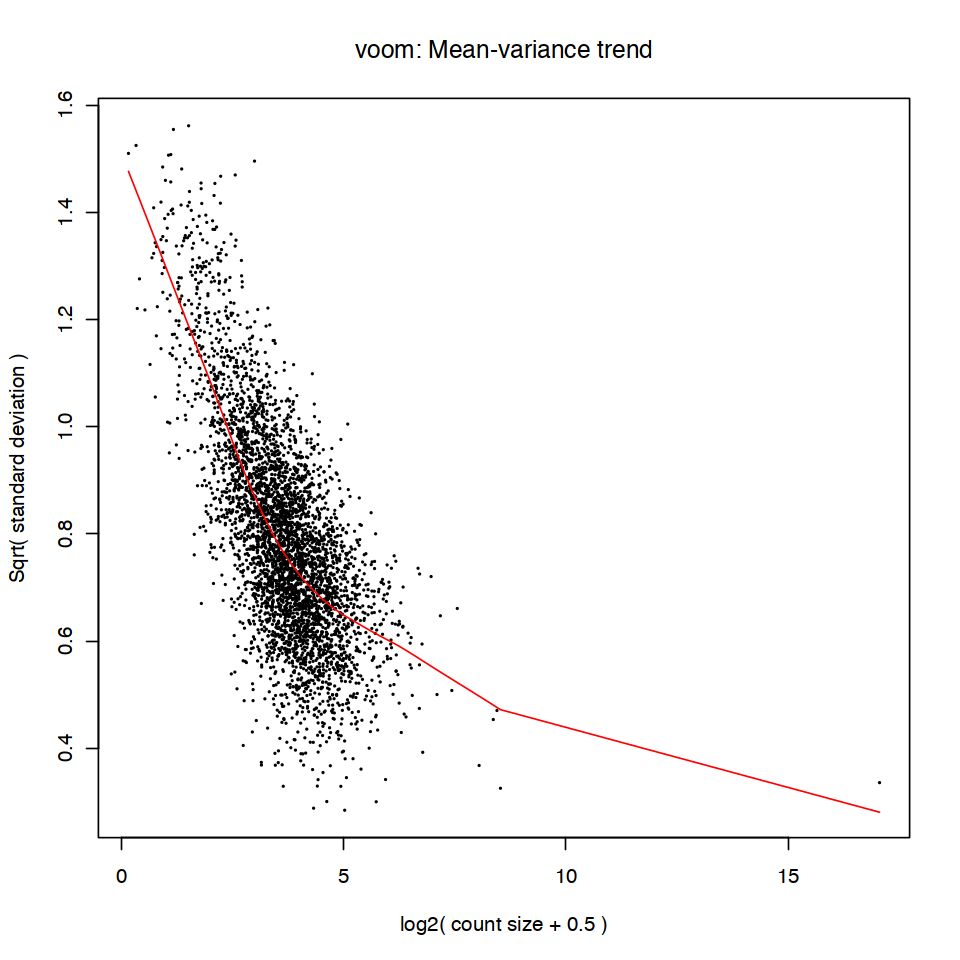

[1]  9781946 13629687 18578643 14538111 17917217 20876327
[1] 14047364 18919596 19940428 14538111 18021990 27416917
[1] 138516      6
[1] "HU"  "HU"  "HU"  "unt" "unt" "unt"


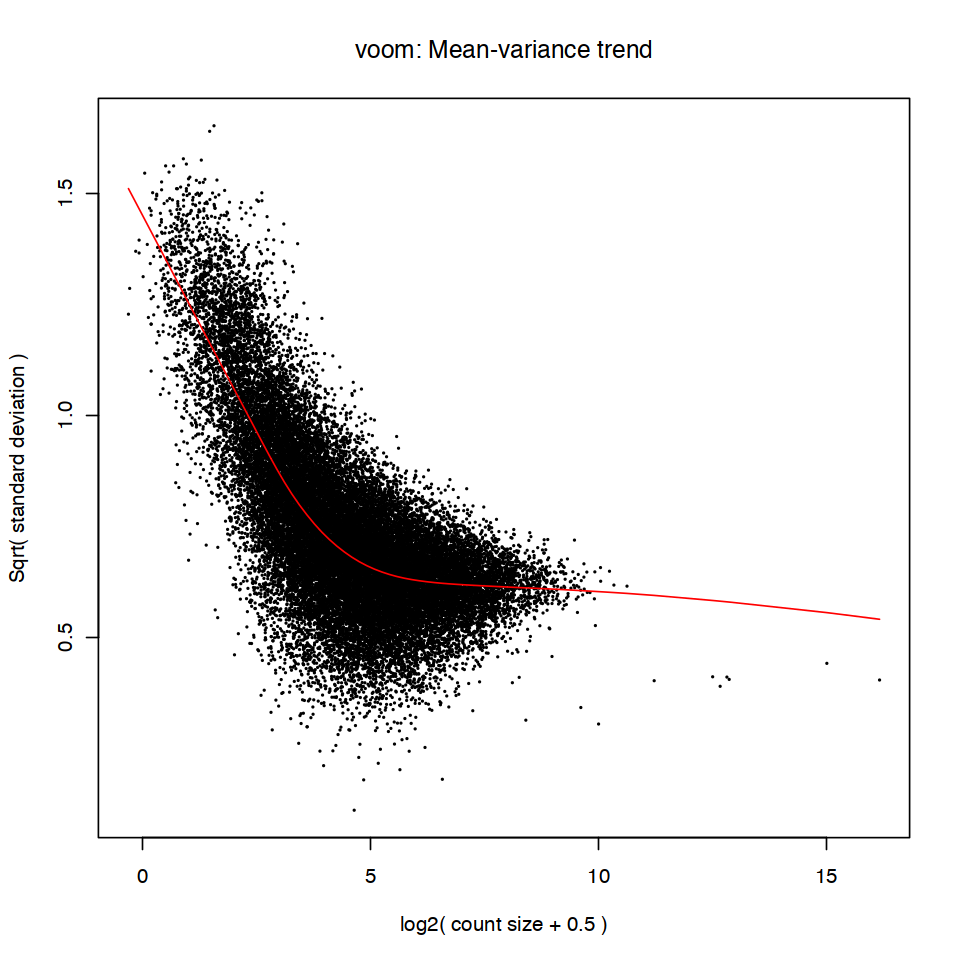

[1] 18087158 13483729 19559507 21056625 17788083 16875590
[1] 23202725 15546316 19854416 24261898 18139996 16875590
[1] 74387     6
[1] "HU"  "HU"  "HU"  "unt" "unt" "unt"


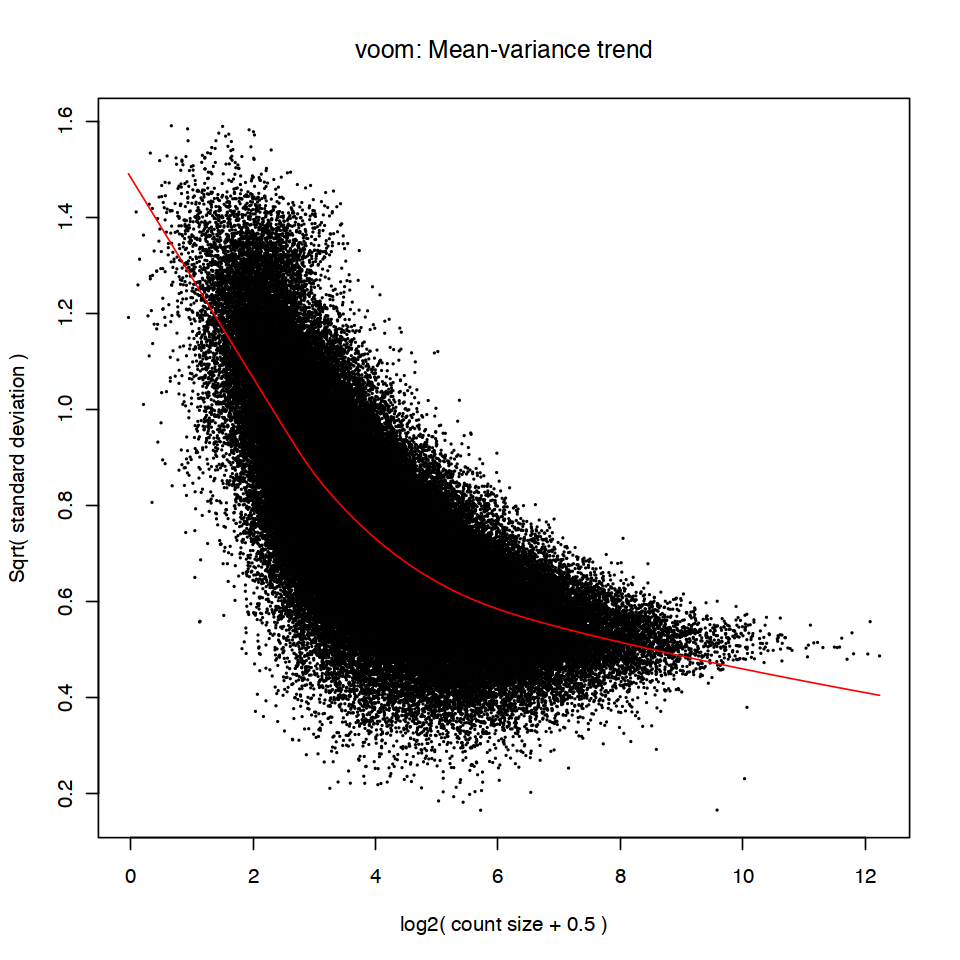

[1] 13589952 14414673 12934621 18396732 15019016 16059778
[1] 26253979 29918012 19625699 20033792 16597297 16059778
[1] 37740     6
[1] "HU"  "HU"  "HU"  "unt" "unt" "unt"


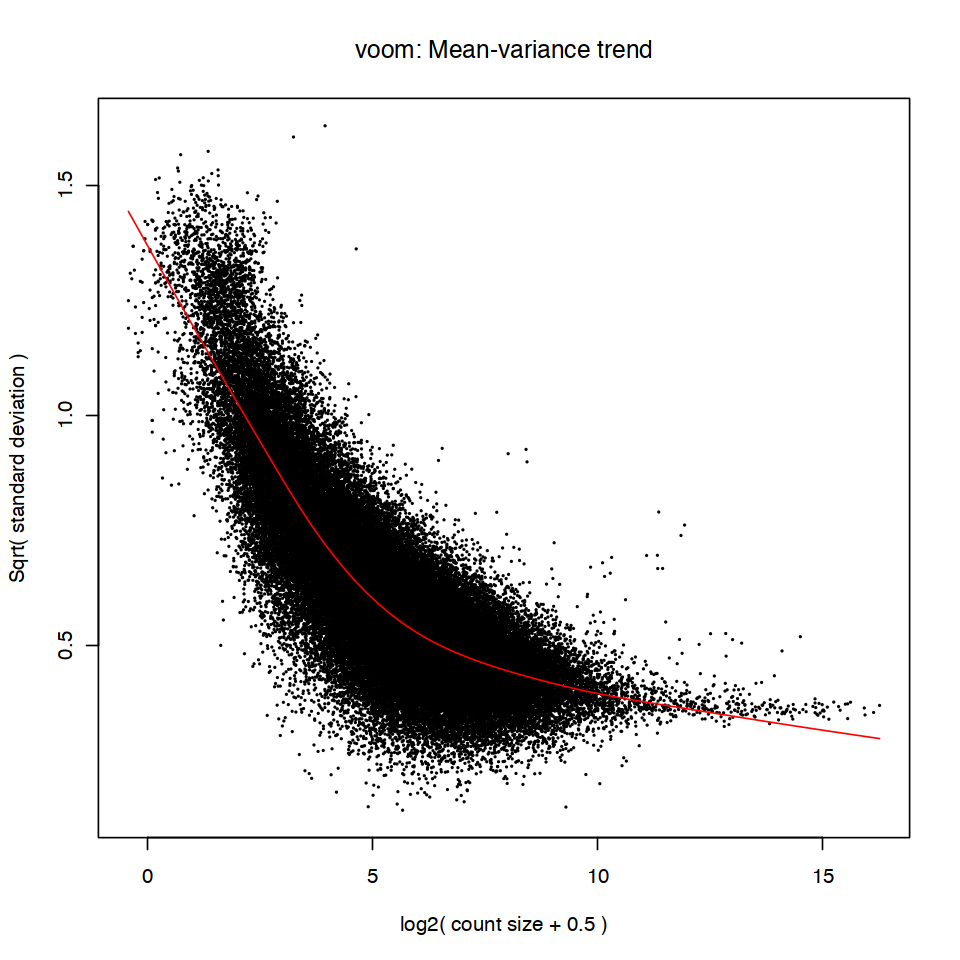

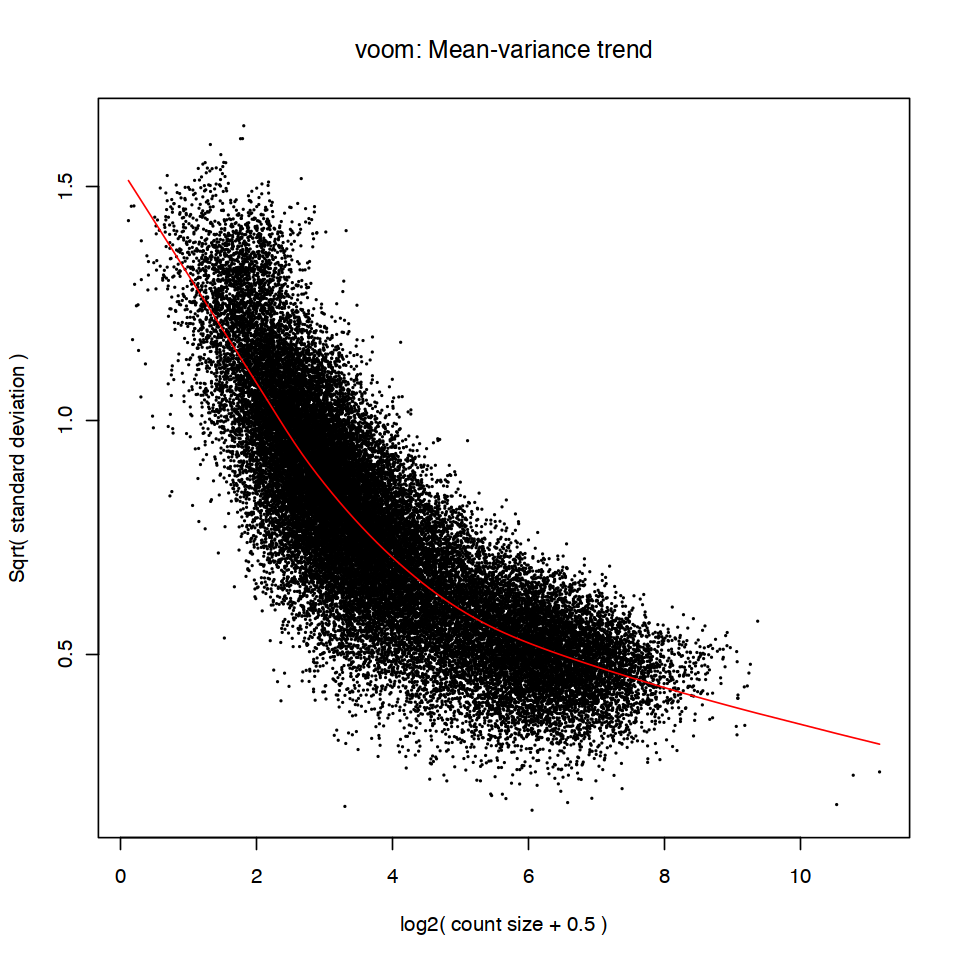

In [204]:
#Normalized to mouse
g9a.g9apeaks.ms = get_fit(g9a.cr$g9a.peaks, norm_to_mouse=T)
wiz.wizpeaks.ms = get_fit(wiz.cr$wiz.peaks, norm_to_mouse=T)
h3k9me2.k9me2peaks.ms = get_fit(h3k9me2.cr$h3k9me2.peaks, norm_to_mouse=T)
h3k9me3.k9me3peaks.ms = get_fit(h3k9me3.cr$h3k9me3.peaks, norm_to_mouse=T)
h3k9ac.k9acpeaks.ms = get_fit(h3k9ac.cr$h3k9ac.peaks, norm_to_mouse=T)

### Norm to mouse

In [205]:
#Norm to mouse
g9a.g9apeaks.ms.dep = process_res(g9a.g9apeaks.ms[[1]], makeContrasts("condsHU-condsunt", levels = colnames(coef(g9a.g9apeaks.ms[[1]]))))
wiz.wizpeaks.ms.dep = process_res(wiz.wizpeaks.ms[[1]], makeContrasts("condsHU-condsunt", levels = colnames(coef(wiz.wizpeaks.ms[[1]]))))
h3k9me2.k9me2peaks.ms.dep = process_res(h3k9me2.k9me2peaks.ms[[1]], makeContrasts("condsHU-condsunt", levels = colnames(coef(h3k9me2.k9me2peaks.ms[[1]]))))
h3k9me3.k9me3peaks.ms.dep = process_res(h3k9me3.k9me3peaks.ms[[1]], makeContrasts("condsHU-condsunt", levels = colnames(coef(h3k9me3.k9me3peaks.ms[[1]]))))
h3k9ac.k9acpeaks.ms.dep = process_res(h3k9ac.k9acpeaks.ms[[1]], makeContrasts("condsHU-condsunt", levels = colnames(coef(h3k9ac.k9acpeaks.ms[[1]]))))

Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_point()`).”


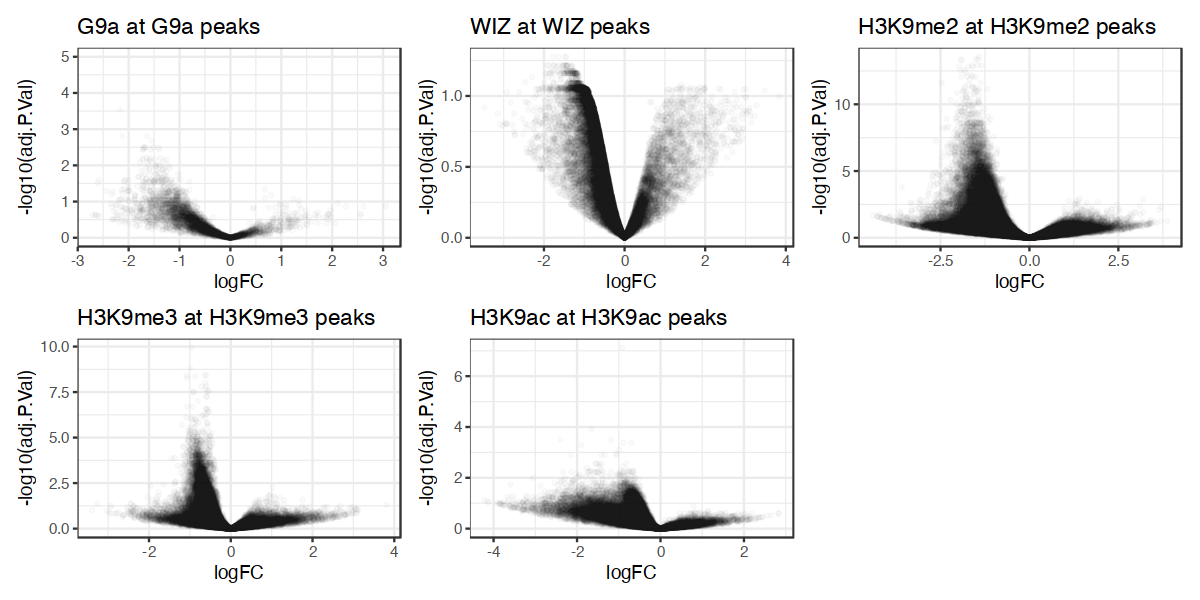

In [155]:
#Norm to mouse
#Note: set FDR at 0.1 instead of 0.05 to allow WIZ to have some differential peaks
#I think the norm to mouse creates higher variance in some of the samples

g1 = ggplot(g9a.g9apeaks.ms.dep, aes(x=logFC, y=-log10(adj.P.Val))) + 
rasterize(geom_point(alpha=0.02, size=1), dpi=300) + theme_bw() + ggtitle("G9a at G9a peaks") + ylim(c(0,5))
g2 = ggplot(wiz.wizpeaks.ms.dep, aes(x=logFC, y=-log10(adj.P.Val))) + 
rasterize(geom_point(alpha=0.02, size=1), dpi=300) + theme_bw() + ggtitle("WIZ at WIZ peaks")
g3 = ggplot(h3k9me2.k9me2peaks.ms.dep, aes(x=logFC, y=-log10(adj.P.Val))) + 
rasterize(geom_point(alpha=0.02, size=1), dpi=300) + theme_bw() + ggtitle("H3K9me2 at H3K9me2 peaks")
g4 = ggplot(h3k9me3.k9me3peaks.ms.dep, aes(x=logFC, y=-log10(adj.P.Val))) + 
rasterize(geom_point(alpha=0.02, size=1), dpi=300) + theme_bw() + ggtitle("H3K9me3 at H3K9me3 peaks")
g5 = ggplot(h3k9ac.k9acpeaks.ms.dep, aes(x=logFC, y=-log10(adj.P.Val))) + 
rasterize(geom_point(alpha=0.02, size=1), dpi=300) + theme_bw() + ggtitle("H3K9ac at H3K9ac peaks")
g1 + g2 + g3 + g4 + g5 + plot_layout(nrow=2)

ggsave("../results//250924_volcanoplots_mouse_norm.pdf", width=12, height=6)

In [210]:
dim(subset(g9a.g9apeaks.ms.dep, logFC < -0.5 & adj.P.Val < 0.1))
dim(subset(g9a.g9apeaks.ms.dep, logFC > 0.5 & adj.P.Val < 0.1))
dim(subset(wiz.wizpeaks.ms.dep, logFC < -0.5 & adj.P.Val < 0.1))
dim(subset(wiz.wizpeaks.ms.dep, logFC > 0.5 & adj.P.Val < 0.1))
dim(subset(h3k9me2.k9me2peaks.ms.dep, logFC < -0.5 & adj.P.Val < 0.1))
dim(subset(h3k9me2.k9me2peaks.ms.dep, logFC > 0.5 & adj.P.Val < 0.1))
dim(subset(h3k9me3.k9me3peaks.ms.dep, logFC < -0.5 & adj.P.Val < 0.1))
dim(subset(h3k9me3.k9me3peaks.ms.dep, logFC > 0.5 & adj.P.Val < 0.1))
dim(subset(h3k9ac.k9acpeaks.ms.dep, logFC < -0.5 & adj.P.Val < 0.1))
dim(subset(h3k9ac.k9acpeaks.ms.dep, logFC > 0.5 & adj.P.Val < 0.1))

[1] 348   6

[1] 6 6

[1] 1437    6

[1] 37  6

[1] 23311     6

[1] 899   6

[1] 9604    6

[1] 101   6

[1] 2637    6

[1] 0 6

### NOT normalized to mouse

[1] 14589134 13622212 11231840  8673649 12562236 13553610
[1] 14589134 13622212 11231840  8673649 12562236 13553610
[1] 29416     6
[1] "HU"  "HU"  "HU"  "unt" "unt" "unt"
[1] 14589134 13622212 11231840  8673649 12562236 13553610
[1] 14589134 13622212 11231840  8673649 12562236 13553610
[1] 4243    6
[1] "HU"  "HU"  "HU"  "unt" "unt" "unt"


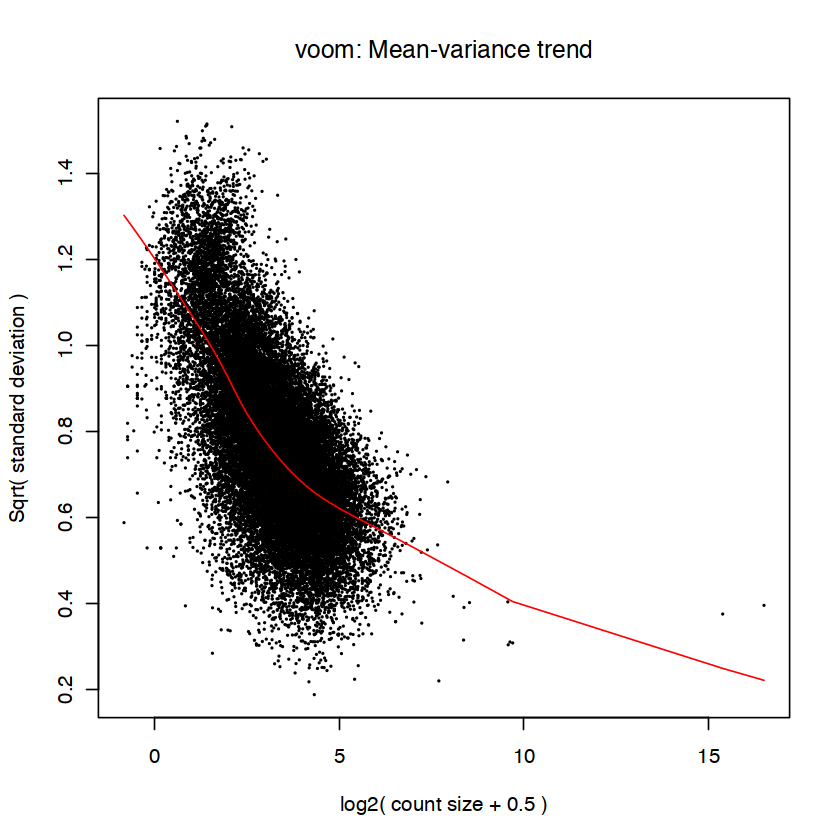

[1]  8786854 15941863  9146268 16447746  8205592 15925601
[1]  8786854 15941863  9146268 16447746  8205592 15925601
[1] 29416     6
[1] "HU"  "HU"  "HU"  "unt" "unt" "unt"


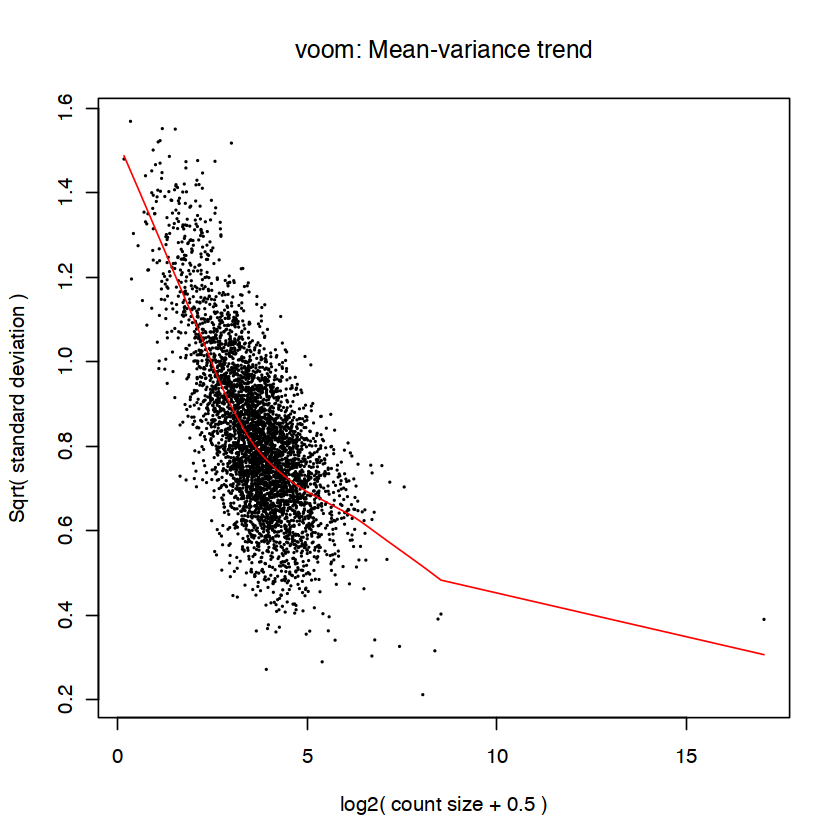

[1]  8786854 15941863  9146268 16447746  8205592 15925601
[1]  8786854 15941863  9146268 16447746  8205592 15925601
[1] 4243    6
[1] "HU"  "HU"  "HU"  "unt" "unt" "unt"


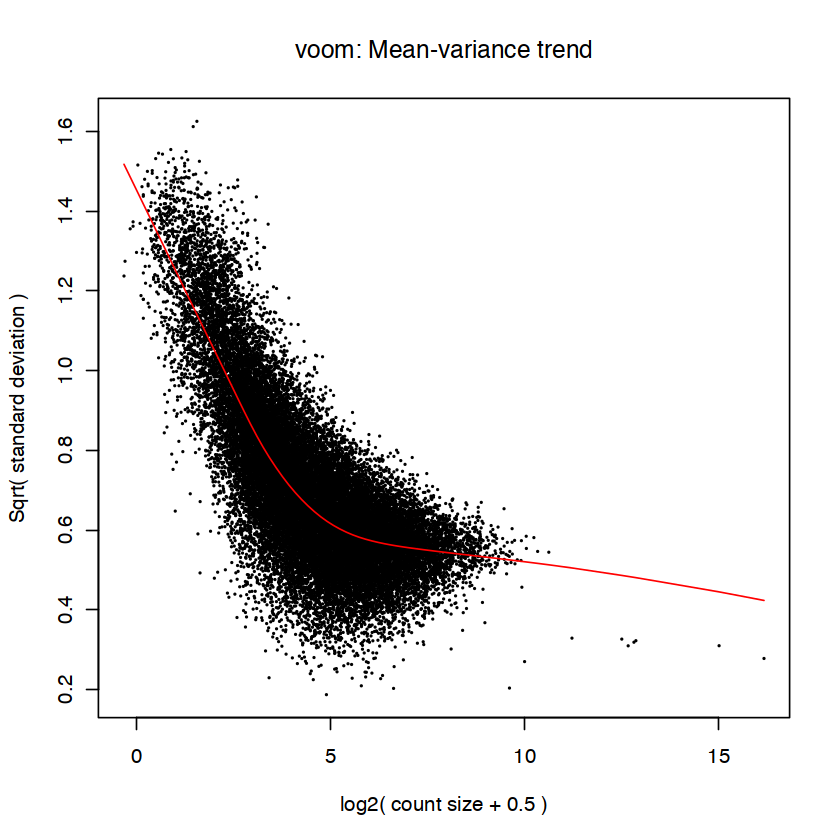

[1]  9781946 13629687 18578643 14538111 17917217 20876327
[1]  9781946 13629687 18578643 14538111 17917217 20876327
[1] 29416     6
[1] "HU"  "HU"  "HU"  "unt" "unt" "unt"


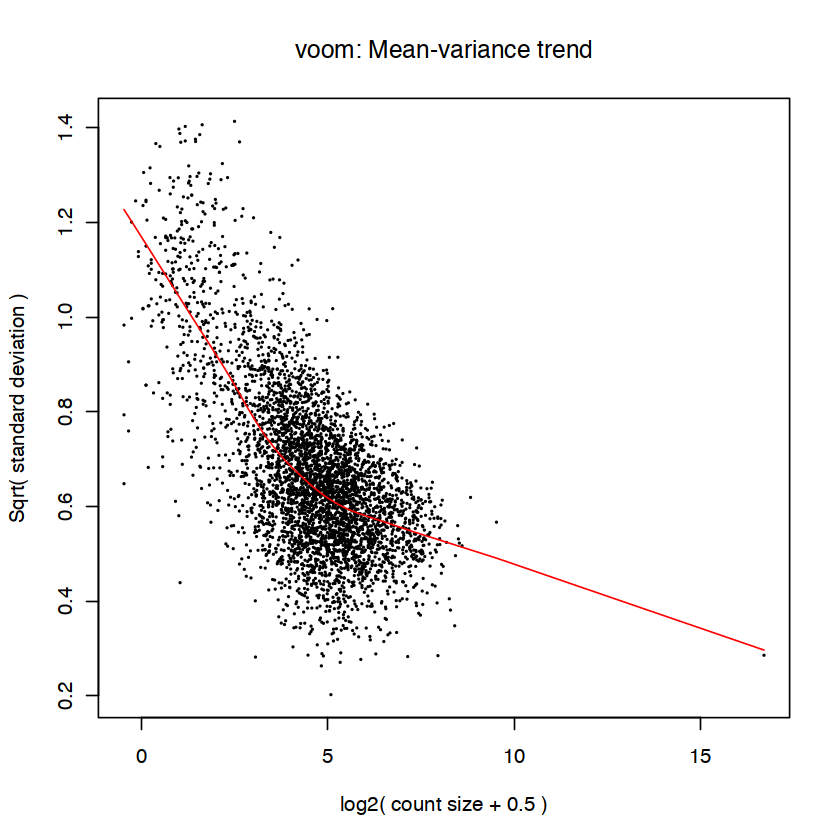

[1]  9781946 13629687 18578643 14538111 17917217 20876327
[1]  9781946 13629687 18578643 14538111 17917217 20876327
[1] 4243    6
[1] "HU"  "HU"  "HU"  "unt" "unt" "unt"


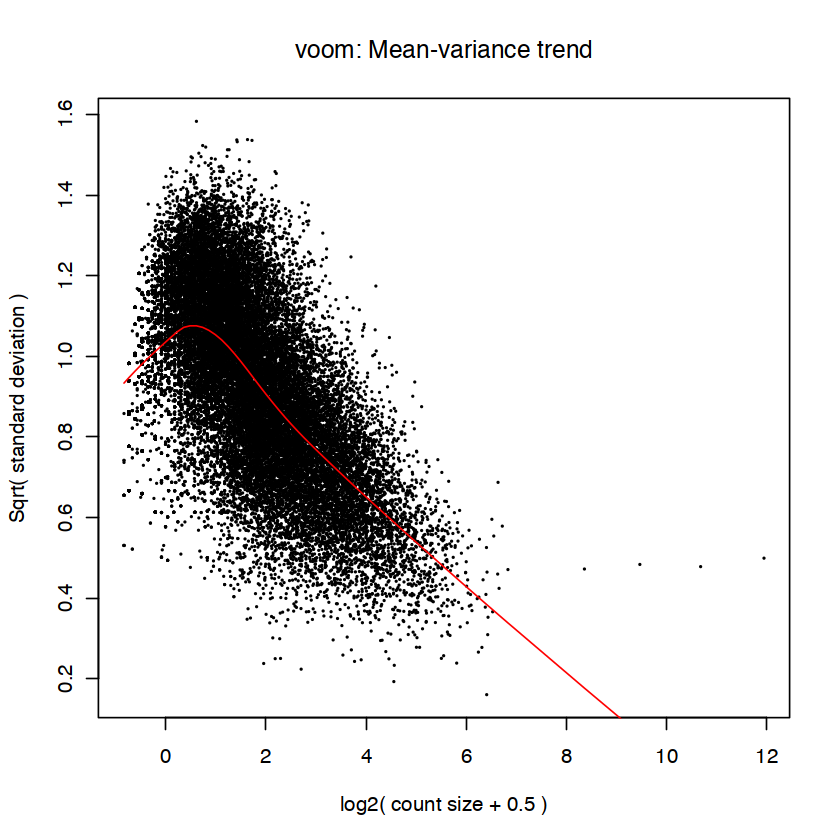

[1]  9781946 13629687 18578643 14538111 17917217 20876327
[1]  9781946 13629687 18578643 14538111 17917217 20876327
[1] 138516      6
[1] "HU"  "HU"  "HU"  "unt" "unt" "unt"


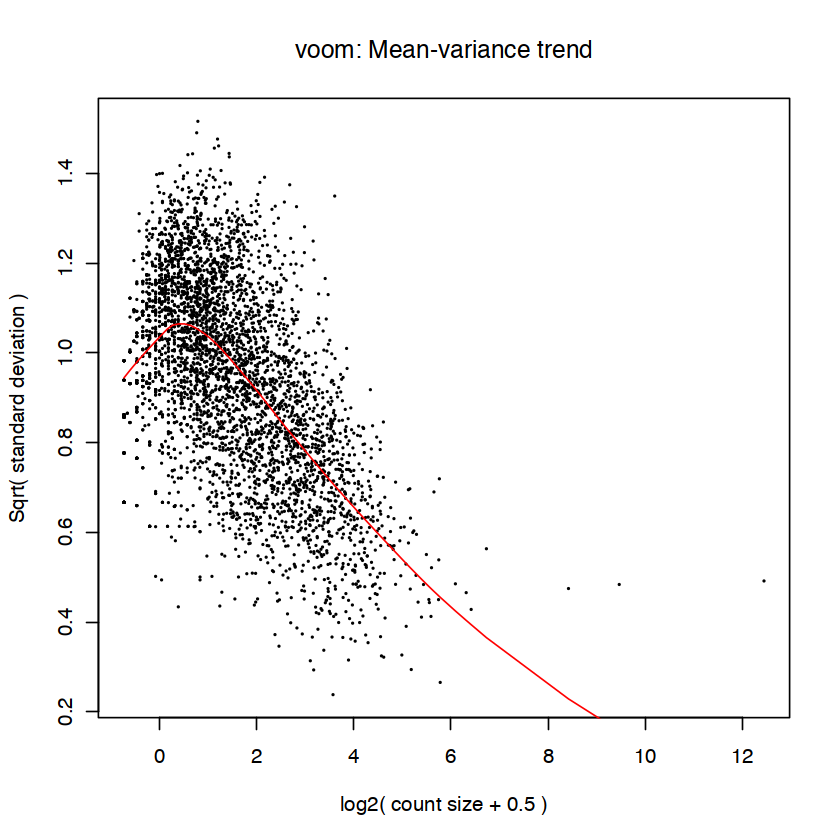

[1]  9781946 13629687 18578643 14538111 17917217 20876327
[1]  9781946 13629687 18578643 14538111 17917217 20876327
[1] 74387     6
[1] "HU"  "HU"  "HU"  "unt" "unt" "unt"


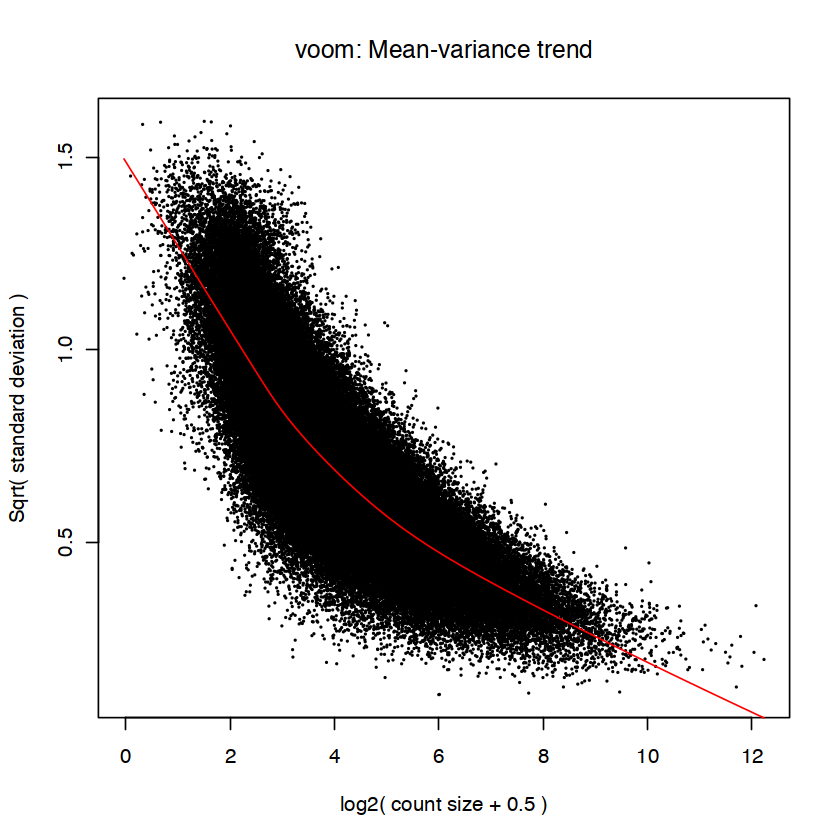

[1]  9781946 13629687 18578643 14538111 17917217 20876327
[1]  9781946 13629687 18578643 14538111 17917217 20876327
[1] 48868     6
[1] "HU"  "HU"  "HU"  "unt" "unt" "unt"


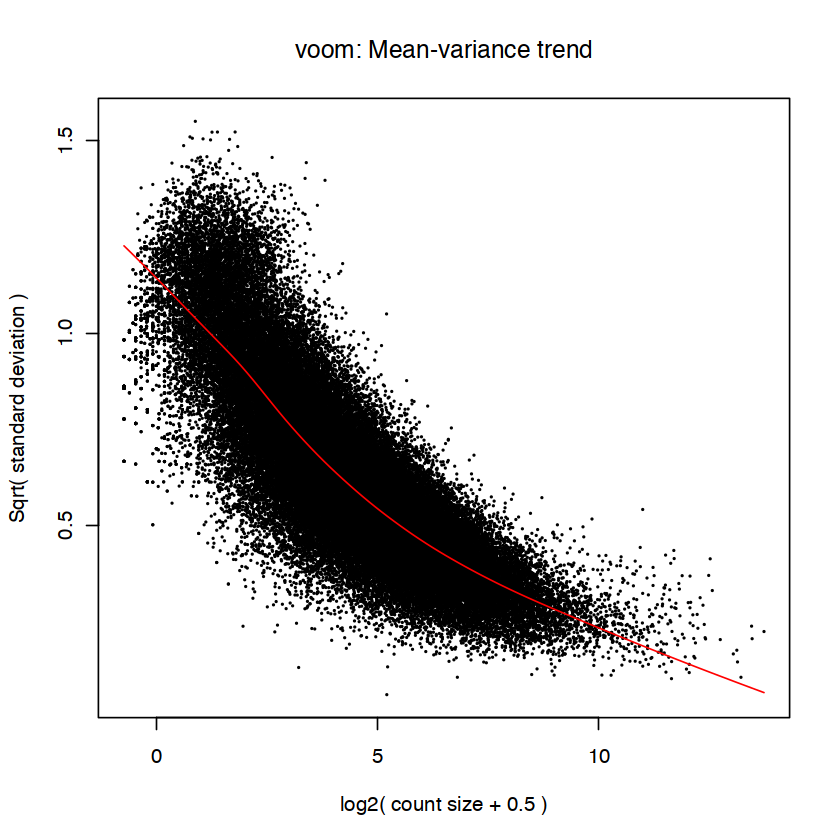

[1] 18087158 13483729 19559507 21056625 17788083 16875590
[1] 18087158 13483729 19559507 21056625 17788083 16875590
[1] 29416     6
[1] "HU"  "HU"  "HU"  "unt" "unt" "unt"


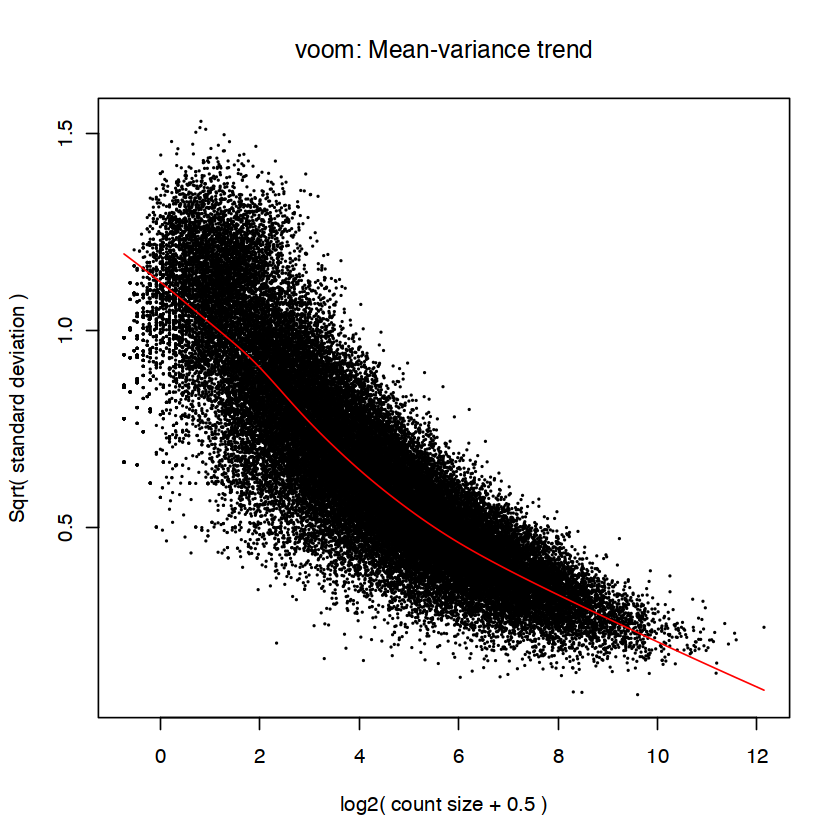

[1] 18087158 13483729 19559507 21056625 17788083 16875590
[1] 18087158 13483729 19559507 21056625 17788083 16875590
[1] 4243    6
[1] "HU"  "HU"  "HU"  "unt" "unt" "unt"


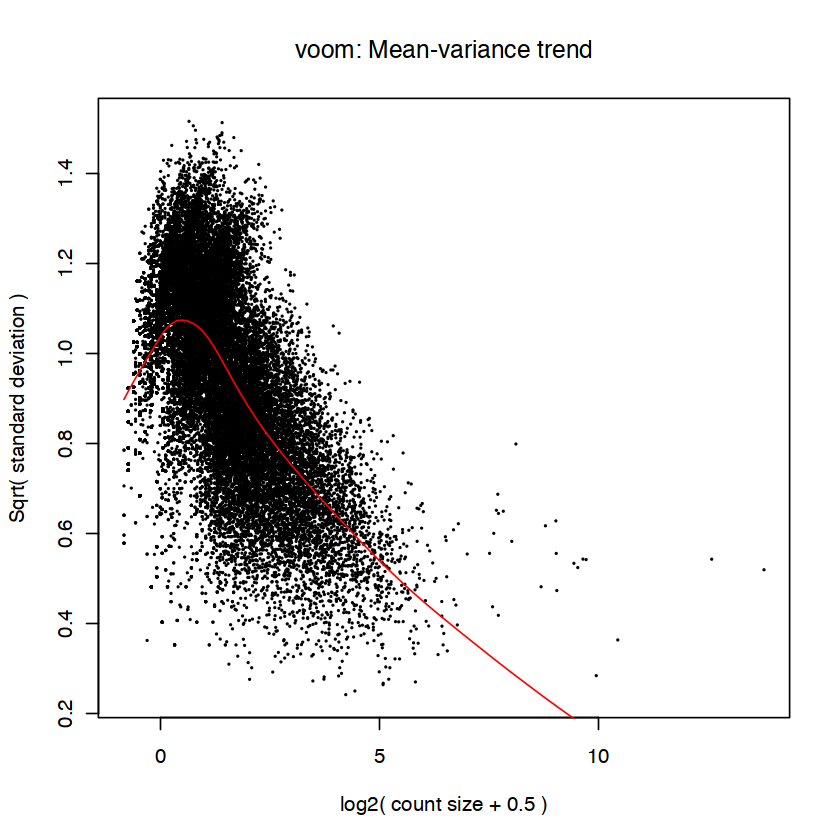

[1] 18087158 13483729 19559507 21056625 17788083 16875590
[1] 18087158 13483729 19559507 21056625 17788083 16875590
[1] 138516      6
[1] "HU"  "HU"  "HU"  "unt" "unt" "unt"


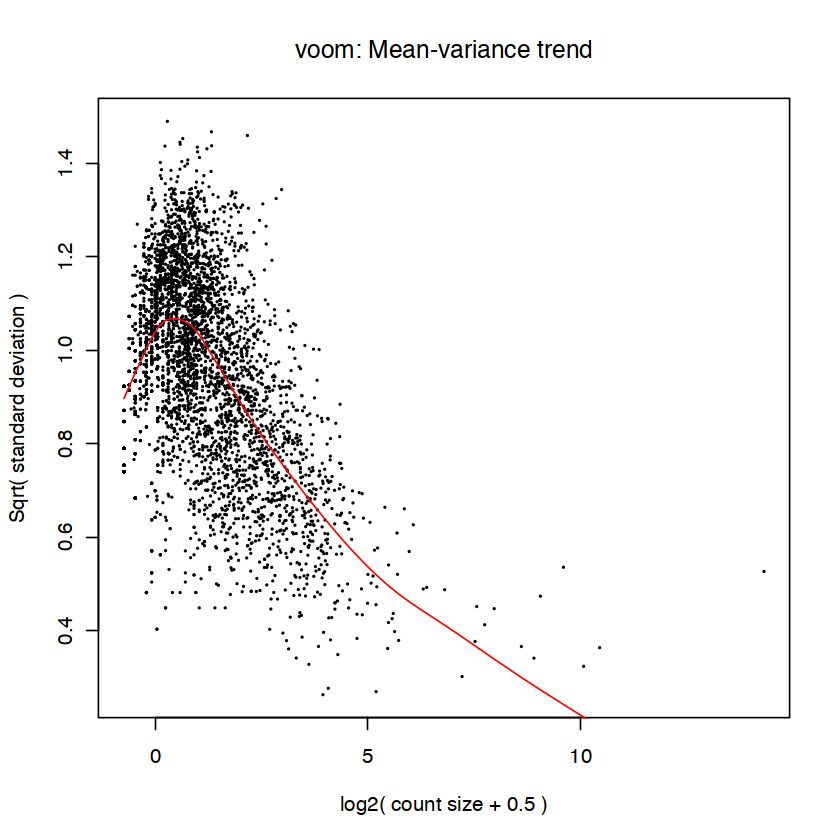

[1] 18087158 13483729 19559507 21056625 17788083 16875590
[1] 18087158 13483729 19559507 21056625 17788083 16875590
[1] 74387     6
[1] "HU"  "HU"  "HU"  "unt" "unt" "unt"


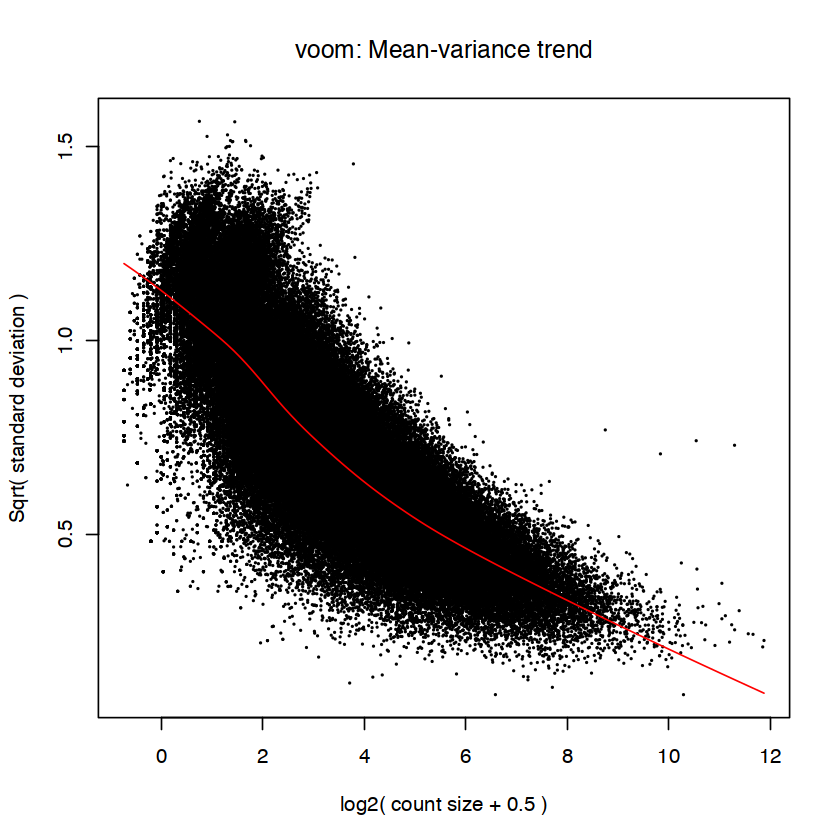

[1] 18087158 13483729 19559507 21056625 17788083 16875590
[1] 18087158 13483729 19559507 21056625 17788083 16875590
[1] 48868     6
[1] "HU"  "HU"  "HU"  "unt" "unt" "unt"


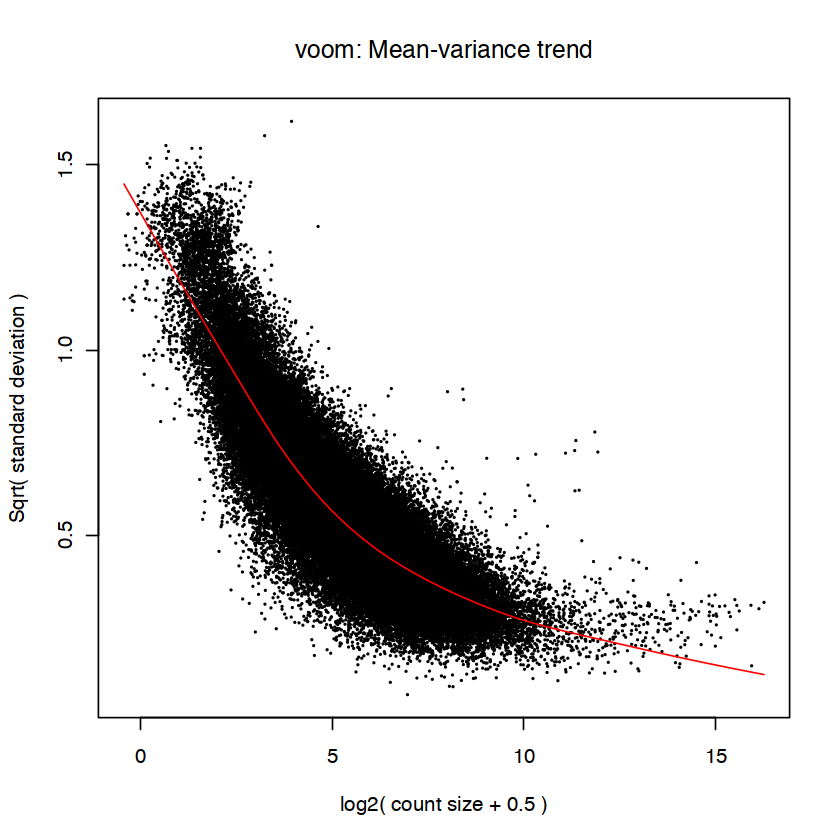

[1] 13589952 14414673 12934621 18396732 15019016 16059778
[1] 13589952 14414673 12934621 18396732 15019016 16059778
[1] 29416     6
[1] "HU"  "HU"  "HU"  "unt" "unt" "unt"


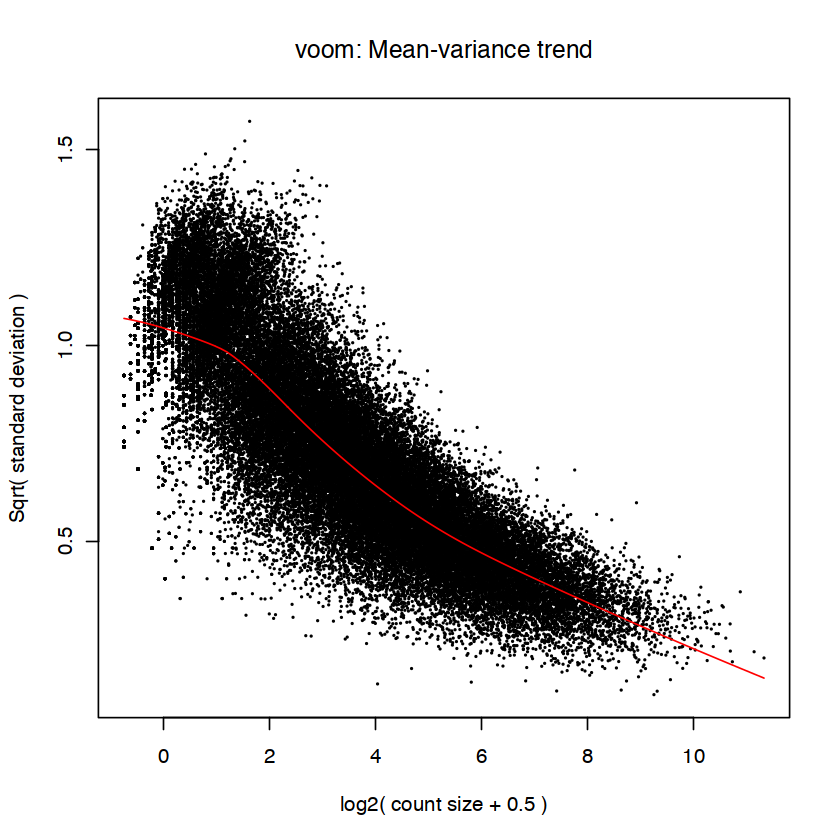

[1] 13589952 14414673 12934621 18396732 15019016 16059778
[1] 13589952 14414673 12934621 18396732 15019016 16059778
[1] 4243    6
[1] "HU"  "HU"  "HU"  "unt" "unt" "unt"


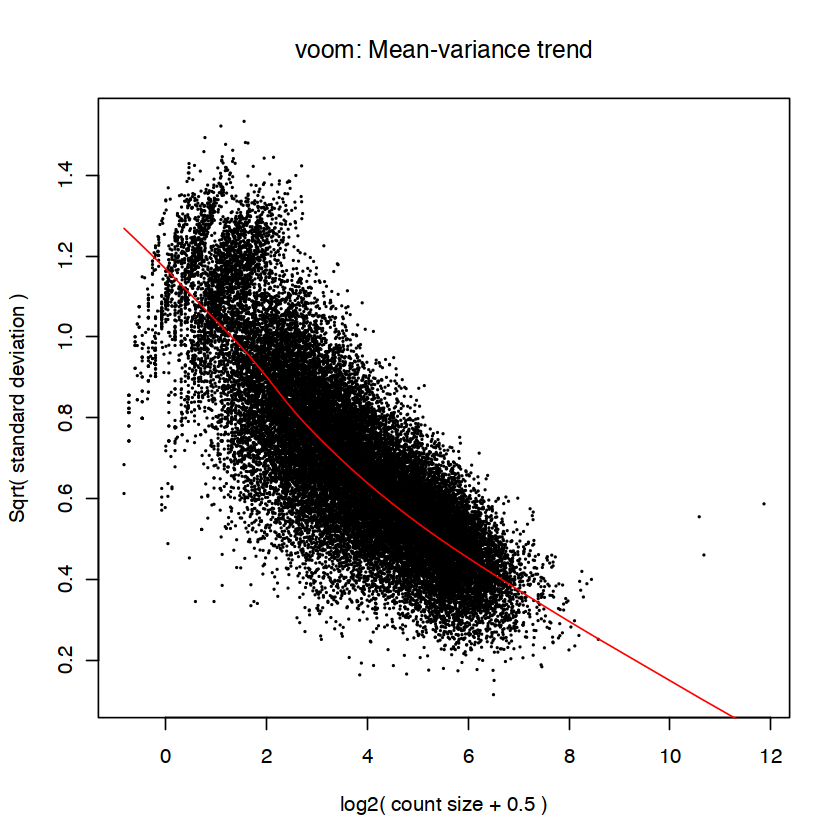

[1] 13589952 14414673 12934621 18396732 15019016 16059778
[1] 13589952 14414673 12934621 18396732 15019016 16059778
[1] 37740     6
[1] "HU"  "HU"  "HU"  "unt" "unt" "unt"


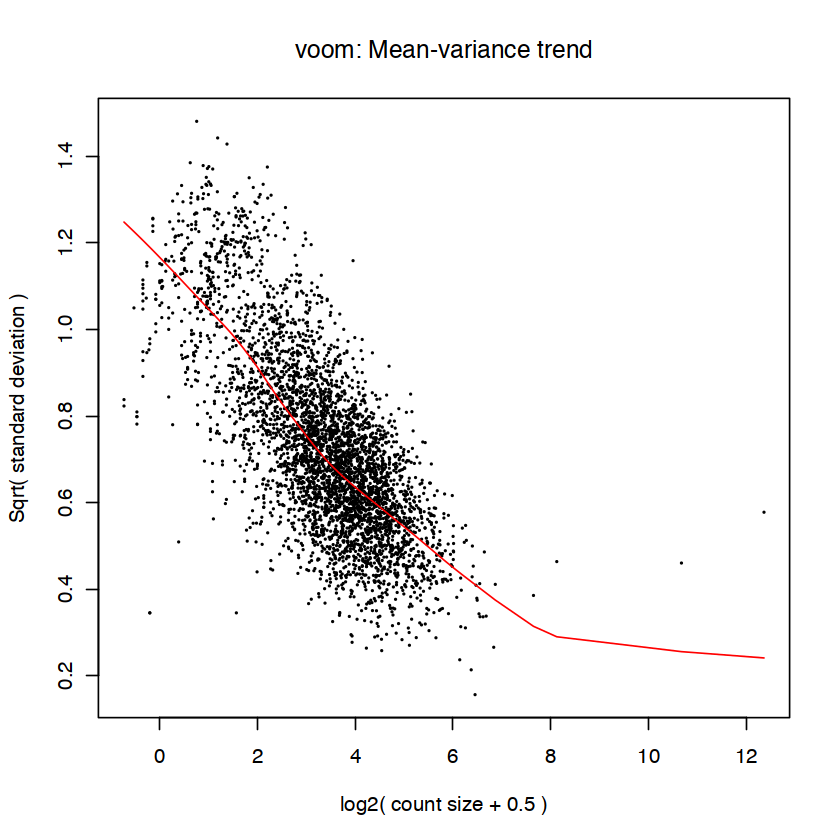

[1] 14838602 17389525 17018041 11244476 15304256 18072352
[1] 14838602 17389525 17018041 11244476 15304256 18072352
[1] 29416     6
[1] "HU"  "HU"  "HU"  "unt" "unt" "unt"


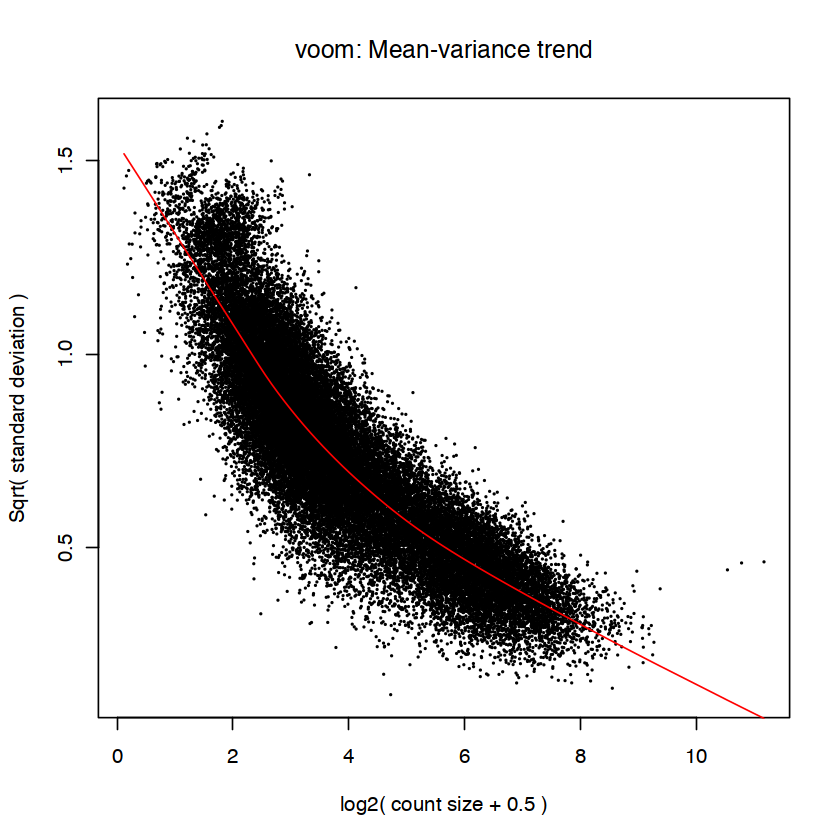

[1] 14838602 17389525 17018041 11244476 15304256 18072352
[1] 14838602 17389525 17018041 11244476 15304256 18072352
[1] 4243    6
[1] "HU"  "HU"  "HU"  "unt" "unt" "unt"


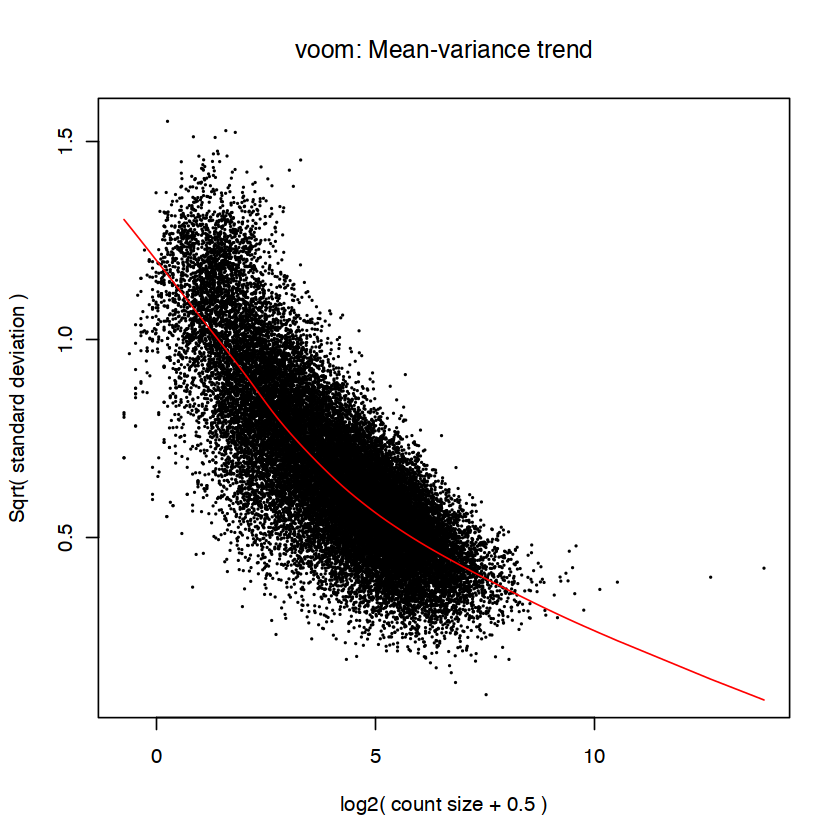

[1] 19445311 17630052 16480374 16870440 12869078
[1] 19445311 17630052 16480374 16870440 12869078
[1] 29416     5
[1] "HU"  "HU"  "unt" "unt" "unt"


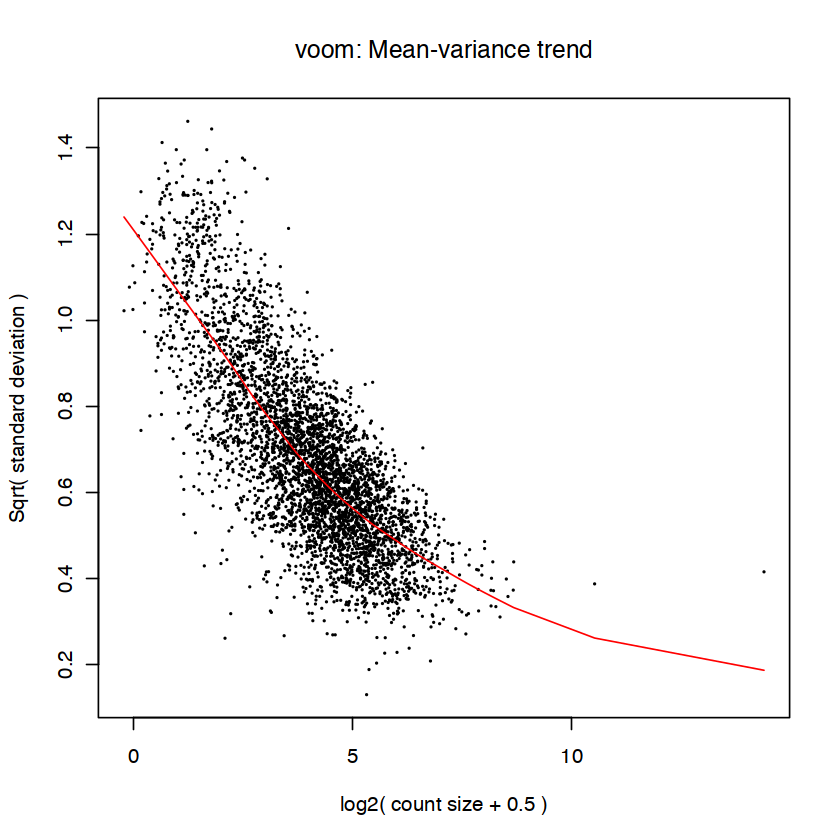

[1] 19445311 17630052 16480374 16870440 12869078
[1] 19445311 17630052 16480374 16870440 12869078
[1] 4243    5
[1] "HU"  "HU"  "unt" "unt" "unt"


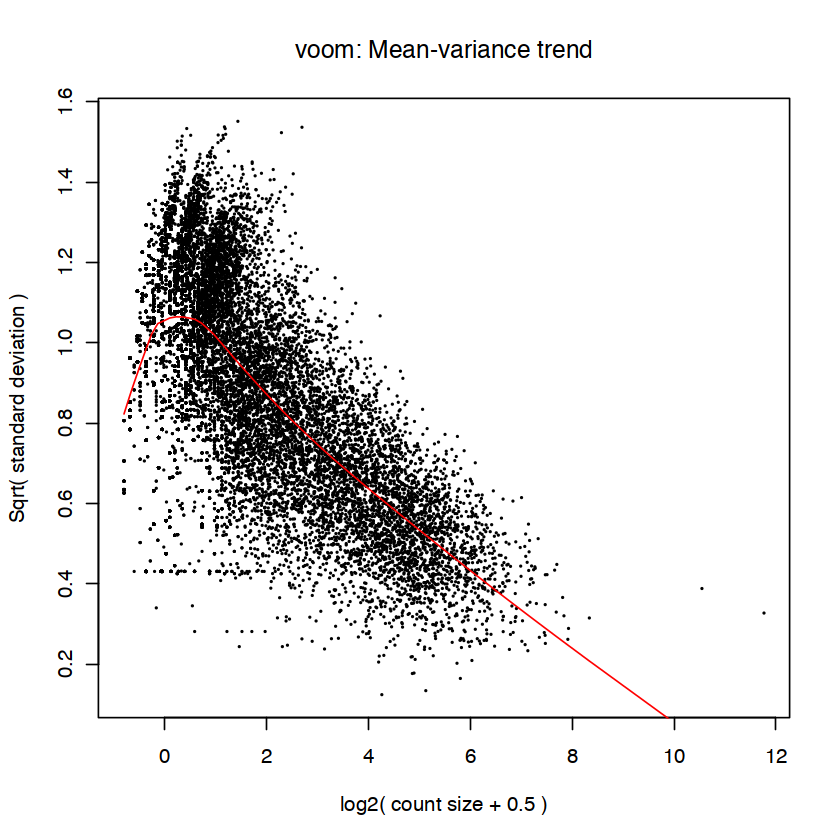

[1] 19445311 17630052 16480374 16870440 12869078
[1] 19445311 17630052 16480374 16870440 12869078
[1] 138516      5
[1] "HU"  "HU"  "unt" "unt" "unt"


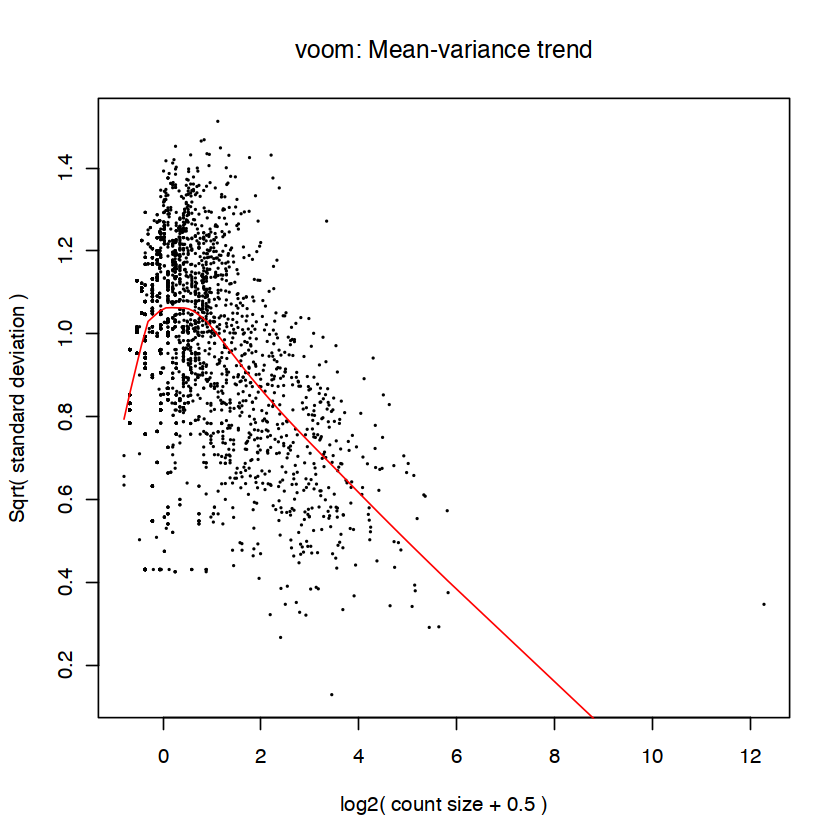

[1] 19445311 17630052 16480374 16870440 12869078
[1] 19445311 17630052 16480374 16870440 12869078
[1] 74387     5
[1] "HU"  "HU"  "unt" "unt" "unt"


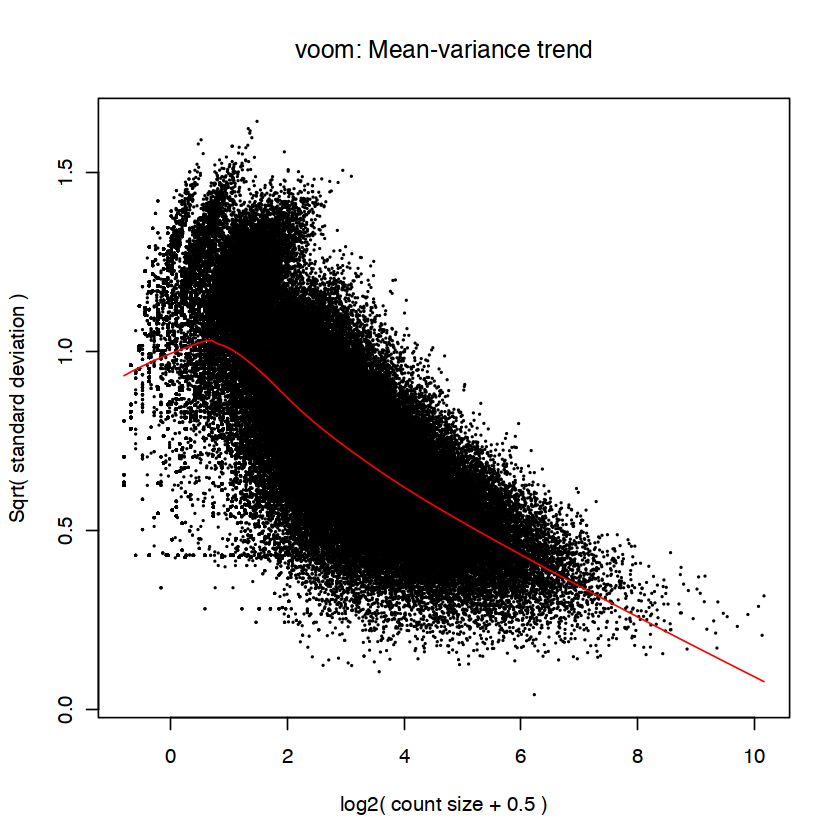

[1] 19445311 17630052 16480374 16870440 12869078
[1] 19445311 17630052 16480374 16870440 12869078
[1] 48868     5
[1] "HU"  "HU"  "unt" "unt" "unt"


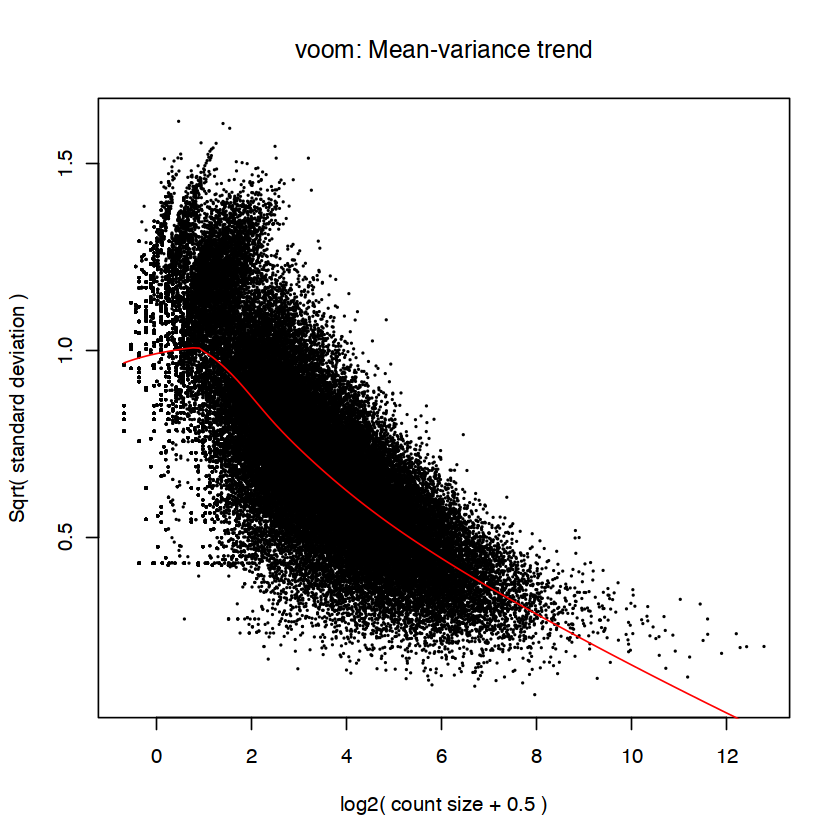

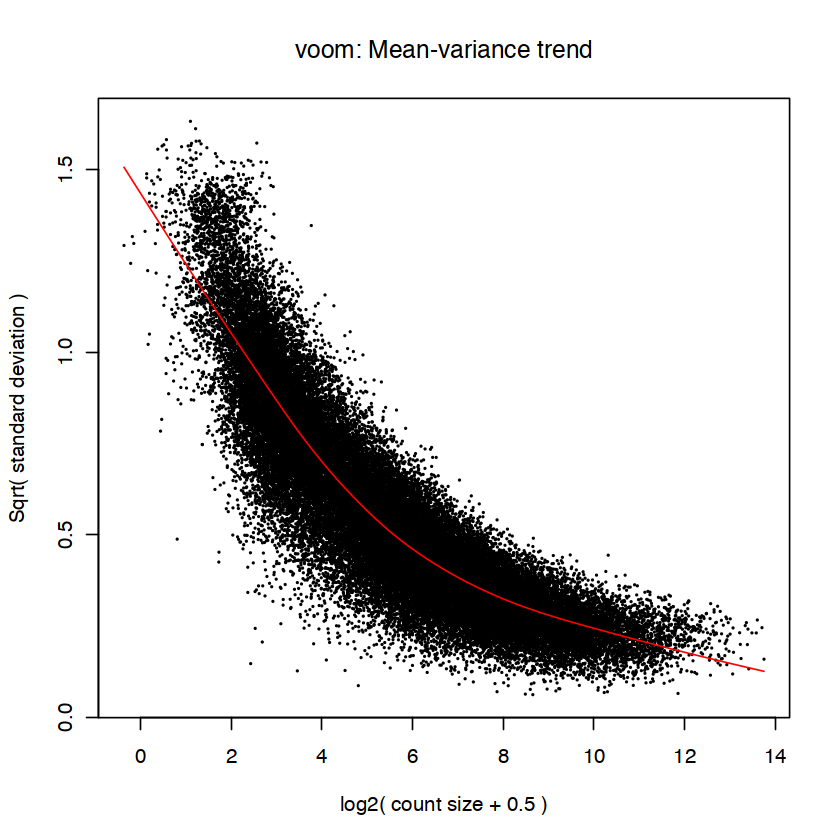

In [13]:
#NOT normalized to mouse
g9a.wizpeaks = get_fit(g9a.cr$wiz.peaks)
g9a.g9apeaks = get_fit(g9a.cr$g9a.peaks)

wiz.wizpeaks = get_fit(wiz.cr$wiz.peaks)
wiz.g9apeaks = get_fit(wiz.cr$g9a.peaks)

h3k9me2.wizpeaks = get_fit(h3k9me2.cr$wiz.peaks)
h3k9me2.g9apeaks = get_fit(h3k9me2.cr$g9a.peaks)
h3k9me2.k9me2peaks = get_fit(h3k9me2.cr$h3k9me2.peaks)
h3k9me2.k9me3peaks = get_fit(h3k9me2.cr$h3k9me3.peaks)
h3k9me2.k27me3peaks = get_fit(h3k9me2.cr$h3k27me3.peaks)

h3k9me3.wizpeaks = get_fit(h3k9me3.cr$wiz.peaks)
h3k9me3.g9apeaks = get_fit(h3k9me3.cr$g9a.peaks)
h3k9me3.k9me2peaks = get_fit(h3k9me3.cr$h3k9me2.peaks)
h3k9me3.k9me3peaks = get_fit(h3k9me3.cr$h3k9me3.peaks)
h3k9me3.k27me3peaks = get_fit(h3k9me3.cr$h3k27me3.peaks)

h3k9ac.wizpeaks = get_fit(h3k9ac.cr$wiz.peaks)
h3k9ac.g9apeaks = get_fit(h3k9ac.cr$g9a.peaks)
h3k9ac.k9acpeaks = get_fit(h3k9ac.cr$h3k9ac.peaks)

h3k27ac.wizpeaks = get_fit(h3k27ac.cr$wiz.peaks)
h3k27ac.g9apeaks = get_fit(h3k27ac.cr$g9a.peaks)

h3k27me3.wizpeaks = get_fit(h3k27me3.cr$wiz.peaks, hu_samples=2)
h3k27me3.g9apeaks = get_fit(h3k27me3.cr$g9a.peaks, hu_samples=2)
h3k27me3.h3k9me2peaks = get_fit(h3k27me3.cr$h3k9me2.peaks, hu_samples=2)
h3k27me3.h3k9me3peaks = get_fit(h3k27me3.cr$h3k9me3.peaks, hu_samples=2)
h3k27me3.k27me3peaks = get_fit(h3k27me3.cr$h3k27me3.peaks, hu_samples=2)


In [14]:
g9a.wizpeaks.dep = process_res(g9a.wizpeaks[[1]], makeContrasts("condsHU-condsunt", levels = colnames(coef(g9a.wizpeaks[[1]]))))
g9a.g9apeaks.dep = process_res(g9a.g9apeaks[[1]], makeContrasts("condsHU-condsunt", levels = colnames(coef(g9a.g9apeaks[[1]]))))

wiz.wizpeaks.dep = process_res(wiz.wizpeaks[[1]], makeContrasts("condsHU-condsunt", levels = colnames(coef(wiz.wizpeaks[[1]]))))
wiz.g9apeaks.dep = process_res(wiz.g9apeaks[[1]], makeContrasts("condsHU-condsunt", levels = colnames(coef(wiz.g9apeaks[[1]]))))

h3k9me2.wizpeaks.dep = process_res(h3k9me2.wizpeaks[[1]], makeContrasts("condsHU-condsunt", levels = colnames(coef(h3k9me2.wizpeaks[[1]]))))
h3k9me2.g9apeaks.dep = process_res(h3k9me2.g9apeaks[[1]], makeContrasts("condsHU-condsunt", levels = colnames(coef(h3k9me2.g9apeaks[[1]]))))
h3k9me2.k9me2peaks.dep = process_res(h3k9me2.k9me2peaks[[1]], makeContrasts("condsHU-condsunt", levels = colnames(coef(h3k9me2.k9me2peaks[[1]]))))
h3k9me2.k9me3peaks.dep = process_res(h3k9me2.k9me3peaks[[1]], makeContrasts("condsHU-condsunt", levels = colnames(coef(h3k9me2.k9me3peaks[[1]]))))
h3k9me2.k27me3peaks.dep = process_res(h3k9me2.k27me3peaks[[1]], makeContrasts("condsHU-condsunt", levels = colnames(coef(h3k9me2.k27me3peaks[[1]]))))

h3k9me3.wizpeaks.dep = process_res(h3k9me3.wizpeaks[[1]], makeContrasts("condsHU-condsunt", levels = colnames(coef(h3k9me3.wizpeaks[[1]]))))
h3k9me3.g9apeaks.dep = process_res(h3k9me3.g9apeaks[[1]], makeContrasts("condsHU-condsunt", levels = colnames(coef(h3k9me3.g9apeaks[[1]]))))
h3k9me3.k9me2peaks.dep = process_res(h3k9me3.k9me2peaks[[1]], makeContrasts("condsHU-condsunt", levels = colnames(coef(h3k9me3.k9me2peaks[[1]]))))
h3k9me3.k9me3peaks.dep = process_res(h3k9me3.k9me3peaks[[1]], makeContrasts("condsHU-condsunt", levels = colnames(coef(h3k9me3.k9me3peaks[[1]]))))
h3k9me3.k27me3peaks.dep = process_res(h3k9me3.k27me3peaks[[1]], makeContrasts("condsHU-condsunt", levels = colnames(coef(h3k9me3.k27me3peaks[[1]]))))

h3k9ac.wizpeaks.dep = process_res(h3k9ac.wizpeaks[[1]], makeContrasts("condsHU-condsunt", levels = colnames(coef(h3k9ac.wizpeaks[[1]]))))
h3k9ac.g9apeaks.dep = process_res(h3k9ac.g9apeaks[[1]], makeContrasts("condsHU-condsunt", levels = colnames(coef(h3k9ac.g9apeaks[[1]]))))
h3k9ac.k9acpeaks.dep = process_res(h3k9ac.k9acpeaks[[1]], makeContrasts("condsHU-condsunt", levels = colnames(coef(h3k9ac.k9acpeaks[[1]]))))

h3k27ac.wizpeaks.dep = process_res(h3k27ac.wizpeaks[[1]], makeContrasts("condsHU-condsunt", levels = colnames(coef(h3k27ac.wizpeaks[[1]]))))
h3k27ac.g9apeaks.dep = process_res(h3k27ac.g9apeaks[[1]], makeContrasts("condsHU-condsunt", levels = colnames(coef(h3k27ac.g9apeaks[[1]]))))

h3k27me3.wizpeaks.dep = process_res(h3k27me3.wizpeaks[[1]], makeContrasts("condsHU-condsunt", levels = colnames(coef(h3k27me3.wizpeaks[[1]]))))
h3k27me3.g9apeaks.dep = process_res(h3k27me3.g9apeaks[[1]], makeContrasts("condsHU-condsunt", levels = colnames(coef(h3k27me3.g9apeaks[[1]]))))
h3k27me3.h3k9me2peaks.dep = process_res(h3k27me3.h3k9me2peaks[[1]], makeContrasts("condsHU-condsunt", levels = colnames(coef(h3k27me3.h3k9me2peaks[[1]]))))
h3k27me3.h3k9me3peaks.dep = process_res(h3k27me3.h3k9me3peaks[[1]], makeContrasts("condsHU-condsunt", levels = colnames(coef(h3k27me3.h3k9me3peaks[[1]]))))
h3k27me3.h3k27me3peaks.dep = process_res(h3k27me3.k27me3peaks[[1]], makeContrasts("condsHU-condsunt", levels = colnames(coef(h3k27me3.k27me3peaks[[1]]))))

## Plot differentially bound peaks

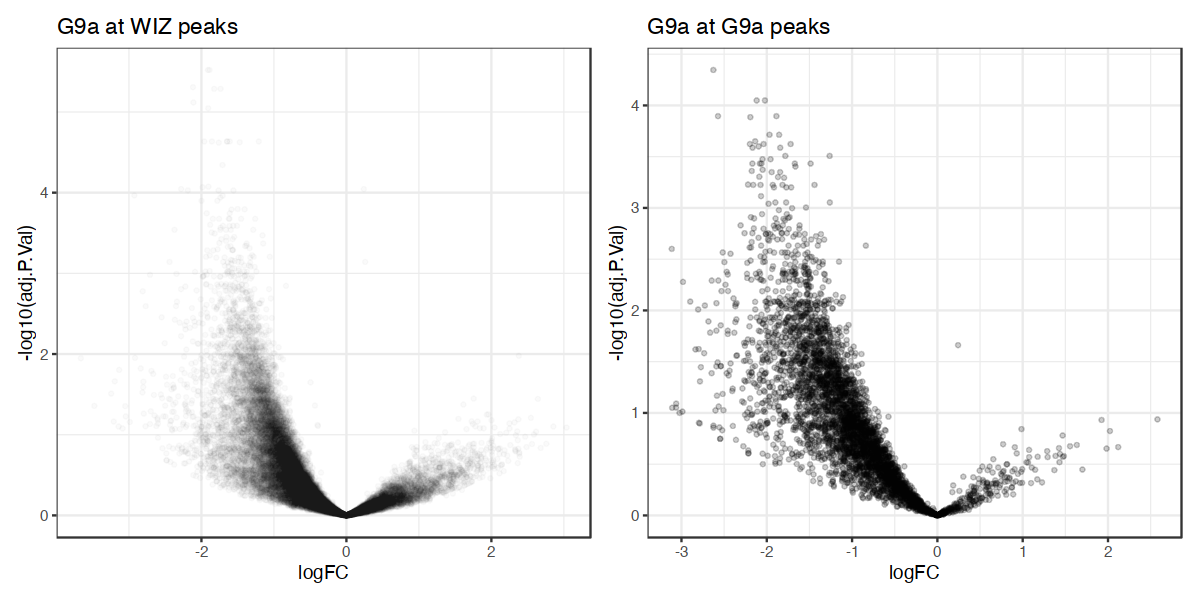

In [38]:
options(repr.plot.width=10, repr.plot.height=5)
g1 = ggplot(g9a.wizpeaks.dep, aes(x=logFC, y=-log10(adj.P.Val))) + rasterize(geom_point(alpha=0.02, size=1), dpi=300) + theme_bw() + ggtitle("G9a at WIZ peaks")
g2 = ggplot(g9a.g9apeaks.dep, aes(x=logFC, y=-log10(adj.P.Val))) + rasterize(geom_point(alpha=0.2, size=1), dpi=300) + theme_bw() + ggtitle("G9a at G9a peaks")
g1 + g2
ggsave("../results/250604_g9a_at_peaks.pdf", width=6, height=2)

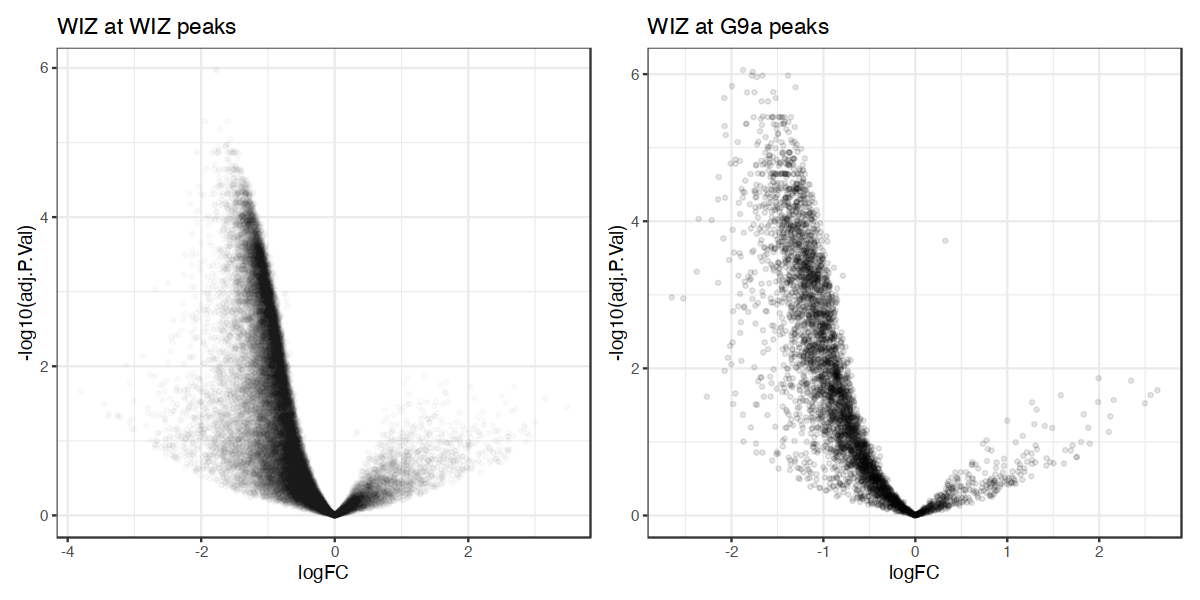

In [37]:
options(repr.plot.width=10, repr.plot.height=5)
g1 = ggplot(wiz.wizpeaks.dep, aes(x=logFC, y=-log10(adj.P.Val))) + rasterize(geom_point(alpha=0.02, size=1), dpi=300) + theme_bw() + ggtitle("WIZ at WIZ peaks")
g2 = ggplot(wiz.g9apeaks.dep, aes(x=logFC, y=-log10(adj.P.Val))) + rasterize(geom_point(alpha=0.1, size=1), dpi=300) + theme_bw() + ggtitle("WIZ at G9a peaks")
g1 + g2
ggsave("../results/250604_wiz_at_peaks.pdf", width=6, height=2)

In [26]:
dim(subset(h3k9me3.k9me3peaks.dep, logFC< -0.5 & adj.P.Val < 0.05))
dim(subset(h3k9me3.k9me3peaks.dep, logFC > 0.5 & adj.P.Val < 0.05))
dim(subset(h3k9me3.k9me3peaks.dep))

[1] 4318    6

[1] 198   6

[1] 74387     6

Warning message:
“Removed 14 rows containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 14 rows containing missing values or values outside the scale range (`geom_point()`).”


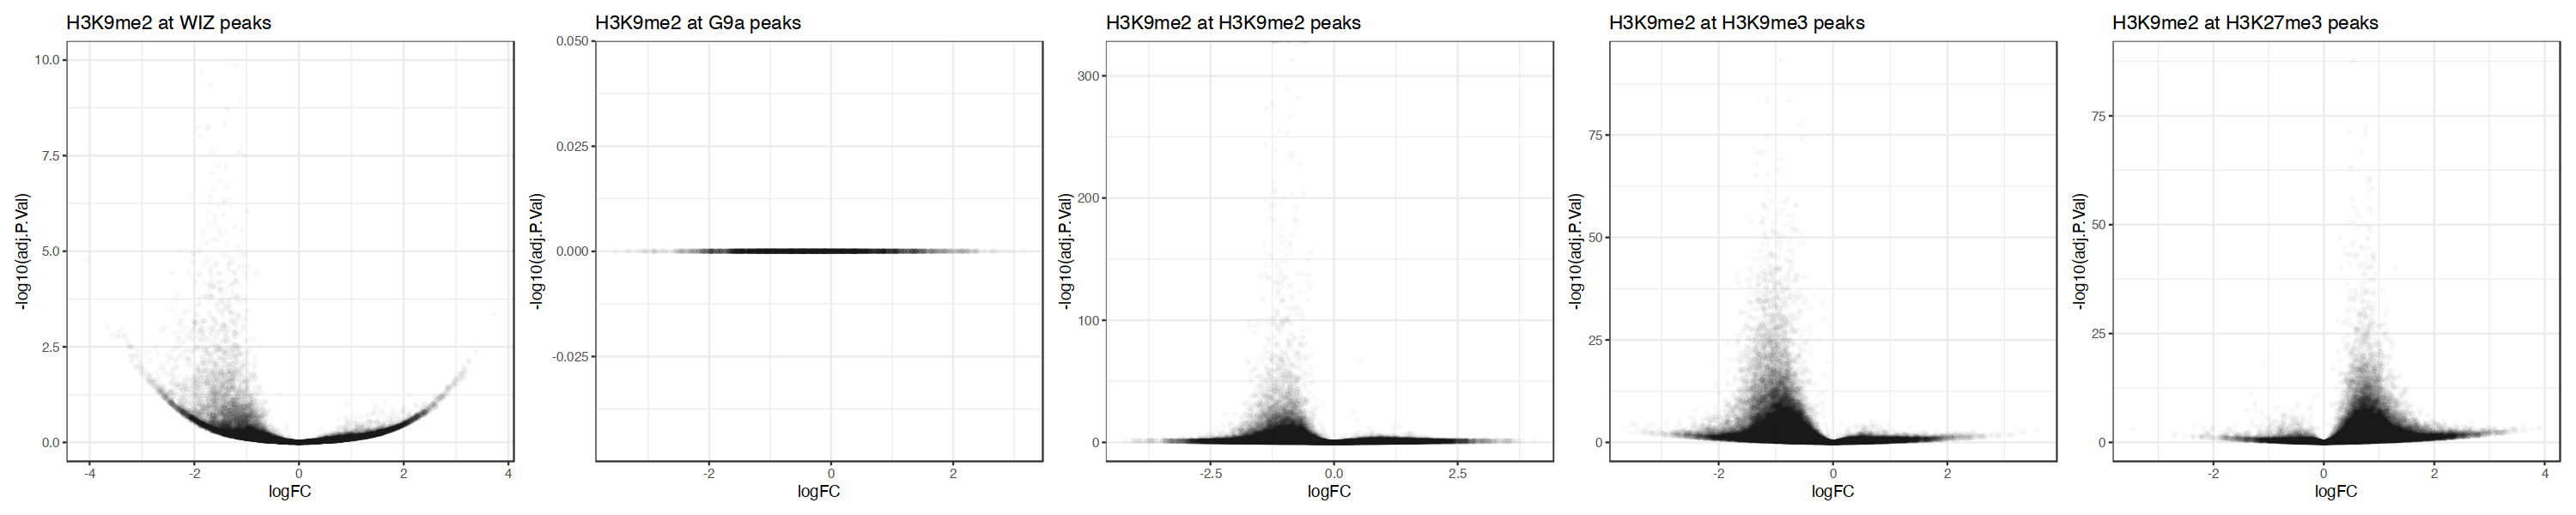

In [34]:
options(repr.plot.width=25, repr.plot.height=5)
g1 = ggplot(h3k9me2.wizpeaks.dep, aes(x=logFC, y=-log10(adj.P.Val))) + rasterize(geom_point(alpha=0.02, size=1), dpi=300) + theme_bw() + ggtitle("H3K9me2 at WIZ peaks") +
ylim(0,10)
g2 = ggplot(h3k9me2.g9apeaks.dep, aes(x=logFC, y=-log10(adj.P.Val))) + rasterize(geom_point(alpha=0.02, size=1), dpi=300) + theme_bw() + ggtitle("H3K9me2 at G9a peaks")
g3 = ggplot(h3k9me2.k9me2peaks.dep, aes(x=logFC, y=-log10(adj.P.Val))) + rasterize(geom_point(alpha=0.02, size=1), dpi=300) + theme_bw() + ggtitle("H3K9me2 at H3K9me2 peaks")
g4 = ggplot(h3k9me2.k9me3peaks.dep, aes(x=logFC, y=-log10(adj.P.Val))) + rasterize(geom_point(alpha=0.02, size=1), dpi=300) + theme_bw() + ggtitle("H3K9me2 at H3K9me3 peaks")
g5 = ggplot(h3k9me2.k27me3peaks.dep, aes(x=logFC, y=-log10(adj.P.Val))) + rasterize(geom_point(alpha=0.02, size=1), dpi=300) + theme_bw() + ggtitle("H3K9me2 at H3K27me3 peaks")
g1 + g2 + g3 + g4 + g5 + plot_layout(nrow=1)
ggsave("../results/250604_h3k9me2_at_peaks.pdf", width=15, height=2)

Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 4 rows containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 4 rows containing missing values or values outside the scale range (`geom_point()`).”


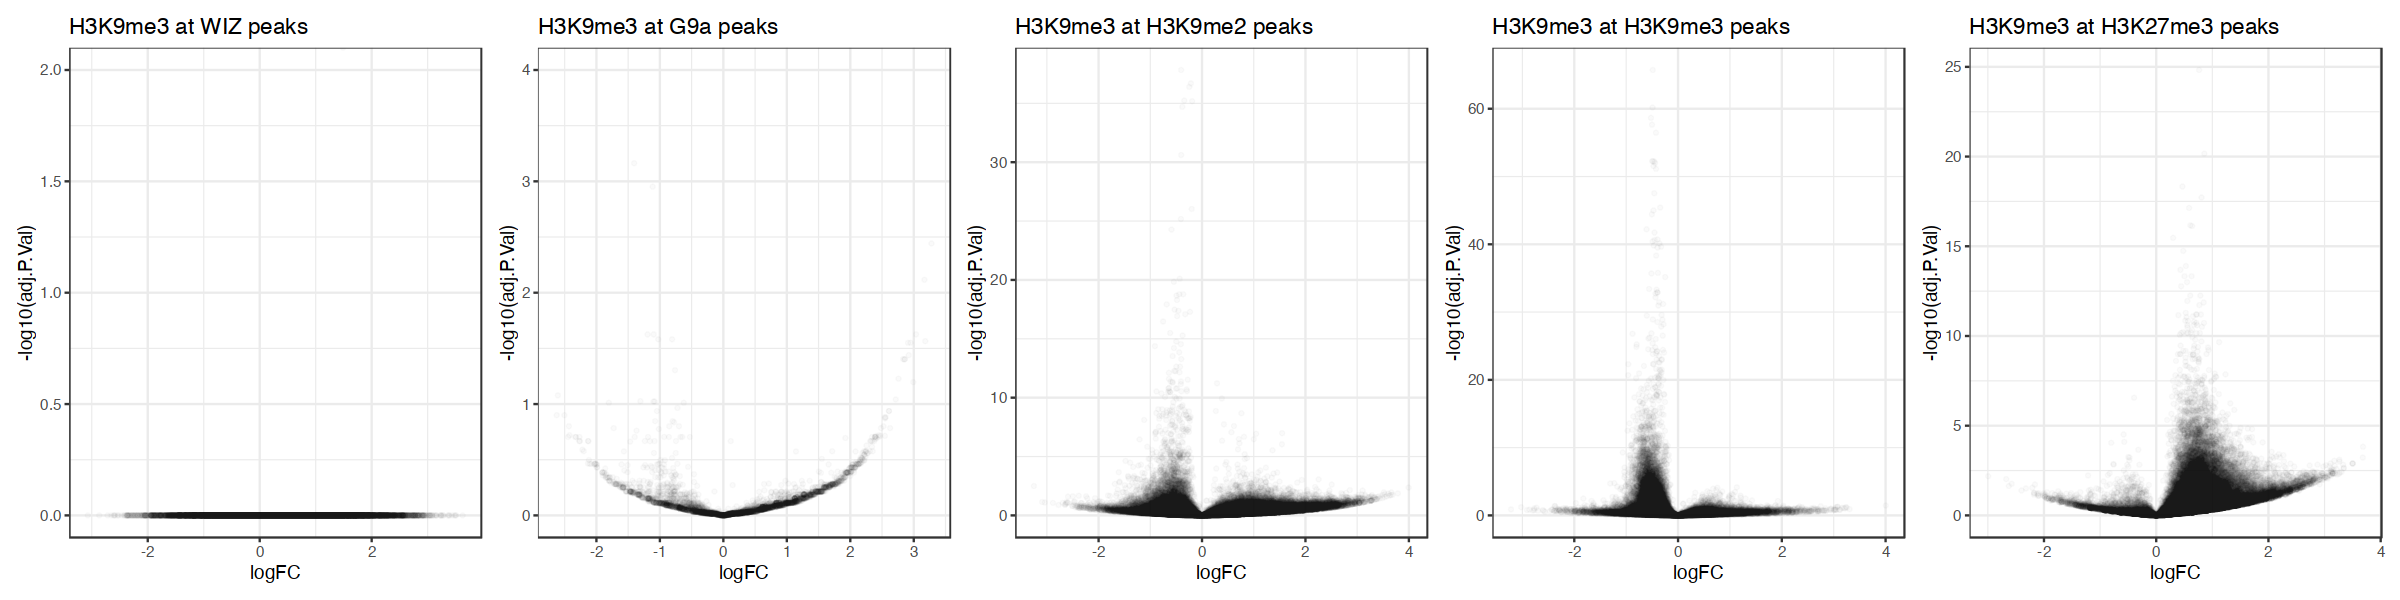

In [35]:
options(repr.plot.width=20, repr.plot.height=5)
g1 = ggplot(h3k9me3.wizpeaks.dep, aes(x=logFC, y=-log10(adj.P.Val))) + rasterize(geom_point(alpha=0.02, size=1), dpi=300) + theme_bw() + ggtitle("H3K9me3 at WIZ peaks") +
ylim(0,2)
g2 = ggplot(h3k9me3.g9apeaks.dep, aes(x=logFC, y=-log10(adj.P.Val))) + rasterize(geom_point(alpha=0.02, size=1), dpi=300) + theme_bw() + ggtitle("H3K9me3 at G9a peaks") +
ylim(0,4)
g3 = ggplot(h3k9me3.k9me2peaks.dep, aes(x=logFC, y=-log10(adj.P.Val))) + rasterize(geom_point(alpha=0.02, size=1), dpi=300) + theme_bw() + ggtitle("H3K9me3 at H3K9me2 peaks")
g4 = ggplot(h3k9me3.k9me3peaks.dep, aes(x=logFC, y=-log10(adj.P.Val))) + rasterize(geom_point(alpha=0.02, size=1), dpi=300) + theme_bw() + ggtitle("H3K9me3 at H3K9me3 peaks")
g5 = ggplot(h3k9me3.k27me3peaks.dep, aes(x=logFC, y=-log10(adj.P.Val))) + rasterize(geom_point(alpha=0.02, size=1), dpi=300) + theme_bw() + ggtitle("H3K9me3 at H3K27me3 peaks")
g1 + g2 + g3 + g4 + g5 + plot_layout(nrow=1)
ggsave("../results/250604_h3k9me3_at_peaks.pdf", width=15, height=2)

Warning message:
“Removed 3 rows containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 4 rows containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 3 rows containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 4 rows containing missing values or values outside the scale range (`geom_point()`).”


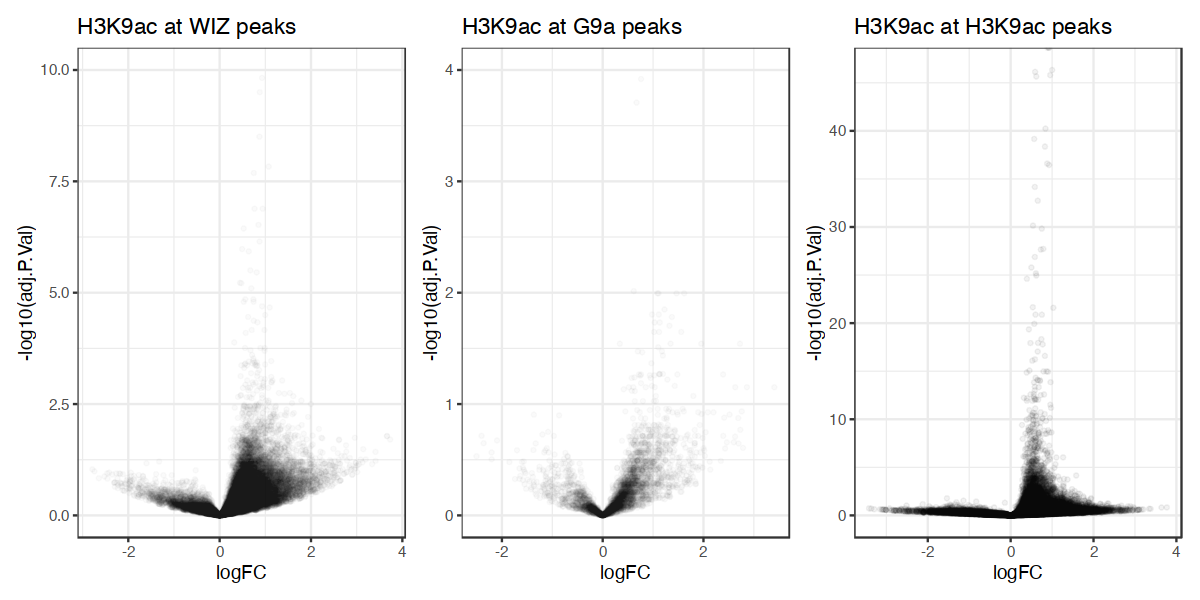

In [36]:
options(repr.plot.width=10, repr.plot.height=5)
g1 = ggplot(h3k9ac.wizpeaks.dep, aes(x=logFC, y=-log10(adj.P.Val))) + rasterize(geom_point(alpha=0.02, size=1), dpi=300) + theme_bw() + ggtitle("H3K9ac at WIZ peaks") +
ylim(0,10)
g2 = ggplot(h3k9ac.g9apeaks.dep, aes(x=logFC, y=-log10(adj.P.Val))) + rasterize(geom_point(alpha=0.02, size=1), dpi=300) + theme_bw() + ggtitle("H3K9ac at G9a peaks") +
ylim(0,4)
g3 = ggplot(h3k9ac.k9acpeaks.dep, aes(x=logFC, y=-log10(adj.P.Val))) + rasterize(geom_point(alpha=0.05, size=1), dpi=300) + theme_bw() + ggtitle("H3K9ac at H3K9ac peaks")
g1 + g2 + g3
ggsave("../results/250604_h3k9ac_at_peaks.pdf", width=9, height=2)

Warning message:
“Removed 3 rows containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 9 rows containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 3 rows containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 9 rows containing missing values or values outside the scale range (`geom_point()`).”


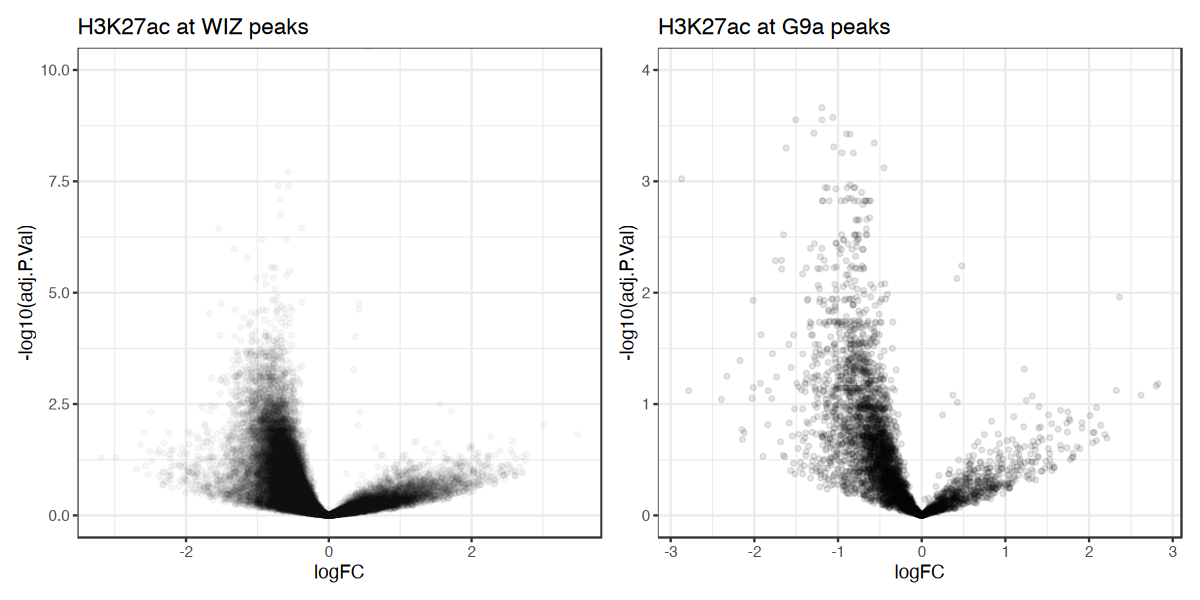

In [96]:
options(repr.plot.width=10, repr.plot.height=5)
g1 = ggplot(h3k27ac.wizpeaks.dep, aes(x=logFC, y=-log10(adj.P.Val))) + geom_point(alpha=0.03, size=1) + theme_bw() + ggtitle("H3K27ac at WIZ peaks") +
ylim(0,10)
g2 = ggplot(h3k27ac.g9apeaks.dep, aes(x=logFC, y=-log10(adj.P.Val))) + geom_point(alpha=0.1, size=1) + theme_bw() + ggtitle("H3K27ac at G9a peaks") +
ylim(0,4)
g1 + g2
ggsave("../results/250604_h3k27ac_at_peaks.pdf", width=6, height=3)

Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 23 rows containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 23 rows containing missing values or values outside the scale range (`geom_point()`).”


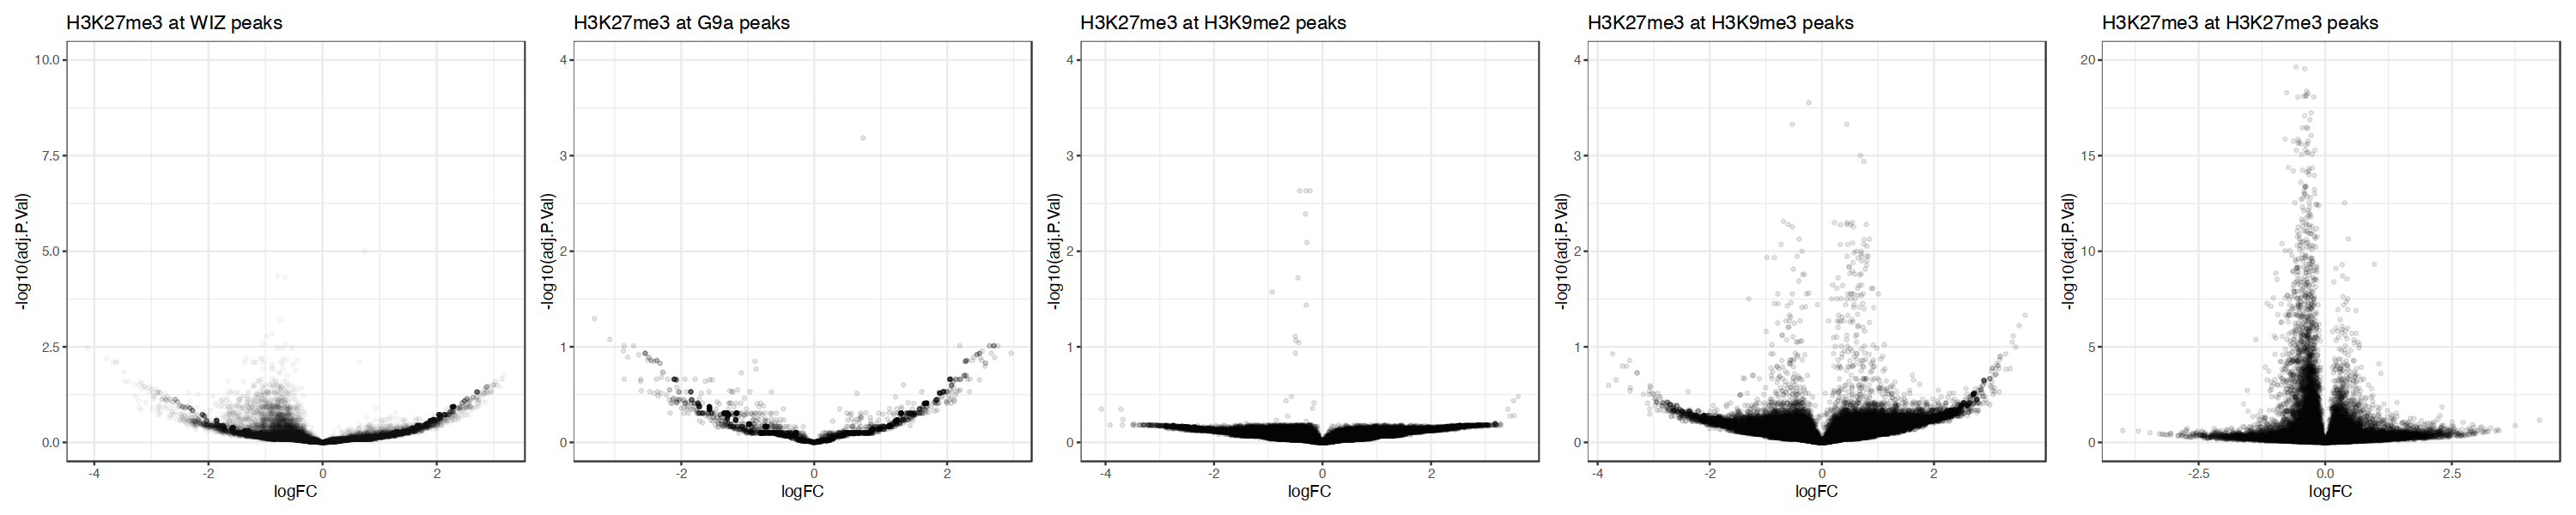

In [61]:
options(repr.plot.width=25, repr.plot.height=5)
g1 = ggplot(h3k27me3.wizpeaks.dep, aes(x=logFC, y=-log10(adj.P.Val))) + rasterize(geom_point(alpha=0.03, size=1), dpi=300) + theme_bw() + ggtitle("H3K27me3 at WIZ peaks") +
ylim(0,10)
g2 = ggplot(h3k27me3.g9apeaks.dep, aes(x=logFC, y=-log10(adj.P.Val))) + rasterize(geom_point(alpha=0.1, size=1), dpi=300) + theme_bw() + ggtitle("H3K27me3 at G9a peaks") +
ylim(0,4)
g3 = ggplot(h3k27me3.h3k9me2peaks.dep, aes(x=logFC, y=-log10(adj.P.Val))) + rasterize(geom_point(alpha=0.1, size=1), dpi=300) + theme_bw() + ggtitle("H3K27me3 at H3K9me2 peaks") +
ylim(0,4)
g4 = ggplot(h3k27me3.h3k9me3peaks.dep, aes(x=logFC, y=-log10(adj.P.Val))) + rasterize(geom_point(alpha=0.1, size=1), dpi=300) + theme_bw() + ggtitle("H3K27me3 at H3K9me3 peaks") +
ylim(0,4)
g5 = ggplot(h3k27me3.h3k27me3peaks.dep, aes(x=logFC, y=-log10(adj.P.Val))) + rasterize(geom_point(alpha=0.1, size=1), dpi=300) + theme_bw() + ggtitle("H3K27me3 at H3K27me3 peaks") +
ylim(0,20)
g1 + g2 + g3 + g4 + g5 + plot_layout(ncol=5)
ggsave("../results/250809_h3k27ac_at_peaks.pdf", width=15, height=3)

In [53]:
dim(subset(h3k27me3.wizpeaks.dep, logFC < -0.5 & adj.P.Val < 0.05)) 
dim(subset(h3k27me3.wizpeaks.dep, logFC > 0.5 & adj.P.Val < 0.05))

dim(subset(h3k27me3.h3k27me3peaks.dep, logFC < -0.5 & adj.P.Val < 0.05)) 
dim(subset(h3k27me3.h3k27me3peaks.dep, logFC > 0.5 & adj.P.Val < 0.05))


[1] 127   6

[1] 62  6

[1] 439   6

[1] 141   6

## Exploration

In [25]:
subset(h3k9me2.peak.info, Geneid=="h3k9me2_peak92170")

,Geneid,Chr,Start,End,Strand,Length
,<chr>,<chr>,<int>,<int>,<chr>,<int>
92170,h3k9me2_peak92170,chr4,174608805,174657229,+,48425


In [26]:
head(h3k9me2.k9me2peaks.dep,20)

,logFC,AveExpr,t,P.Value,adj.P.Val,B
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
h3k9me2_peak80793,-0.5712939,8.132695,-158.81715,0,0,12601.0426
h3k9me2_peak84452,-1.1991278,6.399702,-41.72087,0,0,861.4611
h3k9me2_peak104040,-0.6271407,7.156691,-47.70357,0,0,1128.6788
h3k9me2_peak111393,-1.2629209,6.749078,-54.66286,0,0,1484.8659
h3k9me2_peak111996,-1.2018631,6.348188,-40.11029,0,0,795.6016
h3k9me2_peak123555,-0.9271360,7.085213,-59.97374,0,0,1789.2269
h3k9me2_peak124244,-0.5565632,7.273567,-50.09278,0,0,1245.3783
h3k9me2_peak124260,-1.1492560,6.825502,-55.12923,0,0,1510.4962
h3k9me2_peak125930,-0.6925920,7.108933,-50.14996,0,0,1248.3804


In [43]:
subset(h3k27me3.peak.info, Geneid=="h3k27me3_peak486")

,Geneid,Chr,Start,End,Strand,Length
,<chr>,<chr>,<int>,<int>,<chr>,<int>
486,h3k27me3_peak486,chr1,29664744,29666352,+,1609


In [31]:
head(subset(h3k27me3.h3k27me3peaks.dep, logFC < -1),20)

,logFC,AveExpr,t,P.Value,adj.P.Val,B
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
h3k27me3_peak43268,-1.025490,2.8847181,-6.416134,1.402024e-10,2.729646e-08,12.28009205
h3k27me3_peak48393,-1.147520,2.5704517,-6.299466,2.995155e-10,5.421009e-08,11.09818116
h3k27me3_peak25088,-1.073013,2.7044324,-6.238084,4.441653e-10,7.536622e-08,11.02128377
h3k27me3_peak16866,-1.009289,2.5379844,-5.581412,2.389943e-08,2.678709e-06,7.55466146
h3k27me3_peak6297,-1.369851,1.8476252,-5.491224,3.998187e-08,4.174859e-06,5.78096686
h3k27me3_peak21036,-1.184237,1.8027582,-4.786326,1.700272e-06,1.142901e-04,3.16067567
h3k27me3_peak3143,-1.115501,1.8589380,-4.662637,3.124580e-06,1.888570e-04,2.84622977
h3k27me3_peak2131,-1.147036,1.6511357,-4.397470,1.095972e-05,5.442880e-04,1.68263022
h3k27me3_peak41639,-1.067028,1.7808457,-4.331991,1.478653e-05,6.981527e-04,1.65109250


## Characteristics of H3K9me2/3 and H3K27me3 peaks that change

In [16]:
write_bed = function(peaks, peak_info, fn) {
    df = subset(peak_info, Geneid %in% peaks)
    df2 = cbind(df$Chr, df$Start, df$End, df$Geneid, df$Length, df$Strand)
    write.table(df2, fn, quote=F, sep='\t', row.names = F, col.names = F) 
}

In [ ]:
# characterize them by: baseline H3K9me2, H3K9me3, H3K27me3, H3K4me1, H3K4me3, H3K27ac, ATAC

In [60]:
# H3K9me2
z1 = subset(h3k9me2.k9me2peaks.dep, logFC < -1 & adj.P.Val < 0.05)  # 17369 out of 138k H3K9me2 peaks go down
dim(z1)
z2 = subset(h3k9me2.k9me2peaks.dep, logFC > 0.5 & adj.P.Val < 0.05)  # 2114 out of 138k H3K9me2 peaks go up
dim(z2)
z3 = subset(h3k9me2.k9me2peaks.dep, abs(logFC) < 0.5 | adj.P.Val > 0.05)
dim(z3)

write_bed(rownames(z1), h3k9me2.peak.info, "../results/250809_k9me2_down.bed")
write_bed(rownames(z2), h3k9me2.peak.info, "../results/250809_k9me2_up.bed")
write_bed(rownames(z3), h3k9me2.peak.info, "../results/250809_k9me2_unch.bed")
write_bed(rownames(h3k9me2.k9me2peaks.dep), h3k9me2.peak.info, "../results/250809_k9me2_all.bed")

[1] 8328    6

[1] 2114    6

[1] 119033      6

In [89]:
#H3K9me3
z1 = subset(h3k9me3.k9me3peaks.dep, logFC < -0.5 & adj.P.Val < 0.05)  # 4318 out of 74k H3K9me3 peaks go down
dim(z1)
z2 = subset(h3k9me3.k9me3peaks.dep, logFC > 0.5 & adj.P.Val < 0.05)  # 198 out of 74k H3K9me3 peaks go down
dim(z2)
z3 = subset(h3k9me3.k9me3peaks.dep, abs(logFC) < 0.5 | adj.P.Val > 0.05)
dim(z3)

write_bed(rownames(z1), h3k9me3.peak.info, "../results/250809_k9me3_down.bed")
write_bed(rownames(z2), h3k9me3.peak.info, "../results/250809_k9me3_up.bed")
write_bed(rownames(z3), h3k9me3.peak.info, "../results/250809_k9me3_unch.bed")
write_bed(rownames(h3k9me3.k9me3peaks.dep), h3k9me3.peak.info, "../results/250809_k9me3_all.bed")

[1] 4318    6

[1] 198   6

[1] 69871     6

In [90]:
#H3K27me3
z1 = subset(h3k27me3.h3k27me3peaks.dep, logFC < 0 & adj.P.Val < 0.05)  # 2254 out of 48k H3K27me3 peaks go down
dim(z1)
z2 = subset(h3k27me3.h3k27me3peaks.dep, logFC > 0 & adj.P.Val < 0.05)  # 547 out of 48k H3K27me3 peaks go up
dim(z2)
z3 = subset(h3k27me3.h3k27me3peaks.dep, adj.P.Val > 0.05)
dim(z3)

write_bed(rownames(z1), h3k27me3.peak.info, "../results/250809_k27me3_down.bed")
write_bed(rownames(z2), h3k27me3.peak.info, "../results/250809_k27me3_up.bed")
write_bed(rownames(z3), h3k27me3.peak.info, "../results/250809_k27me3_unch.bed")
write_bed(rownames(h3k27me3.h3k27me3peaks.dep), h3k27me3.peak.info, "../results/250809_k27me3_all.bed")

[1] 2254    6

[1] 547   6

[1] 46067     6

In [32]:
# H3K9ac
z1 = subset(h3k9ac.k9acpeaks.dep, logFC < -0.5 & adj.P.Val < 0.05)  # 4 out of 37740 H3K9ac peaks go down
dim(z1)
z2 = subset(h3k9ac.k9acpeaks.dep, logFC > 0.5 & adj.P.Val < 0.05)  # 2019 out of 37740 H3K9ac peaks go up
dim(z2)
z3 = subset(h3k9ac.k9acpeaks.dep, abs(logFC) < 0.5 | adj.P.Val > 0.05)
dim(z3)

[1] 4 6

[1] 2019    6

[1] 35717     6

In [18]:
z1 = subset(g9a.g9apeaks.dep, logFC < -0.5 & adj.P.Val < 0.05)  # 1135 out of 4243 G9a peaks go down
dim(z1)
z2 = subset(g9a.g9apeaks.dep, logFC > 0.5 & adj.P.Val < 0.05)  # 0 out of 4243 G9a peaks go up
dim(z2)
z3 = subset(g9a.g9apeaks.dep, abs(logFC) < 0.5 | adj.P.Val > 0.05)
dim(z3)
dim(g9a.g9apeaks.dep)


write_bed(rownames(z1), g9a.peak.info, "../results/250809_g9a_down.bed")
write_bed(rownames(z3), g9a.peak.info, "../results/250809_g9a_unch.bed")
#write_bed(rownames(g9a.g9apeaks.dep), h3k9me2.peak.info, "../results/250809_k9me2_all.bed")

[1] 1135    6

[1] 0 6

[1] 3108    6

[1] 4243    6

In [17]:
z1 = subset(wiz.wizpeaks.dep, logFC < -0.5 & adj.P.Val < 0.05)  # 12553 out of 29416 WIZ peaks go down
dim(z1)
z2 = subset(wiz.wizpeaks.dep, logFC > 0.5 & adj.P.Val < 0.05)  # 43 out of 29416 WIZ peaks go up
dim(z2)
z3 = subset(wiz.wizpeaks.dep, abs(logFC) < 0.5 | adj.P.Val > 0.05)
dim(z3)
dim(wiz.wizpeaks.dep)


write_bed(rownames(z1), wiz.peak.info, "../results/250809_wiz_down.bed")
write_bed(rownames(z3), wiz.peak.info, "../results/250809_wiz_unch.bed")

[1] 12553     6

[1] 43  6

[1] 16820     6

[1] 29416     6

In [92]:
write_bed(rownames(wiz.wizpeaks.dep), wiz.peak.info, "../results/250809_wiz_all.bed")
write_bed(rownames(g9a.g9apeaks.dep), g9a.peak.info, "../results/250809_g9a_all.bed")

## H3K9me2 when it is within H3K9me3 vs H3K27me3

In [43]:
h3k9me2.peaks.gr = saf_to_granges(h3k9me2.peak.info)
h3k9me3.peaks.gr = saf_to_granges(h3k9me3.peak.info)
h3k27me3.peaks.gr = saf_to_granges(h3k27me3.peak.info)

wiz.peaks.gr = saf_to_granges(wiz.peak.info)
g9a.peaks.gr = saf_to_granges(g9a.peak.info)

In [50]:
h3k9me2.peak.info$ovl = "none"
h3k9me2.peaks.ovl.k9me3 = findOverlaps(h3k9me2.peaks.gr, h3k9me3.peaks.gr, select="arbitrary")
h3k9me2.peak.info[!is.na(h3k9me2.peaks.ovl.k9me3),]$ovl = "H3K9me3"
h3k9me2.peaks.ovl.k27me3 = findOverlaps(h3k9me2.peaks.gr, h3k27me3.peaks.gr, select="arbitrary")
h3k9me2.peak.info[!is.na(h3k9me2.peaks.ovl.k27me3),]$ovl = "H3K27me3"
h3k9me2.peak.info[!is.na(h3k9me2.peaks.ovl.k27me3) & !is.na(h3k9me2.peaks.ovl.k9me3),]$ovl = "Both"

Warning message in .merge_two_Seqinfo_objects(x, y):
“Each of the 2 combined objects has sequence levels not in the other:
  - in 'x': chr1_KI270711v1_random
  - in 'y': chr11_KI270721v1_random, chr14_GL000194v1_random, chr14_GL000225v1_random, chr14_KI270722v1_random, chr14_KI270723v1_random, chr14_KI270724v1_random, chr15_KI270727v1_random, chr17_KI270729v1_random, chr17_KI270730v1_random, chr1_KI270707v1_random, chr1_KI270709v1_random, chr1_KI270710v1_random, chr1_KI270712v1_random, chr1_KI270713v1_random, chr1_KI270714v1_random, chr22_KI270731v1_random, chr22_KI270732v1_random, chr22_KI270734v1_random, chr22_KI270735v1_random, chr22_KI270736v1_random, chr22_KI270737v1_random, chr22_KI270738v1_random, chr22_KI270739v1_random, chr2_KI270716v1_random, chr5_GL000208v1_random, chr9_KI270719v1_random, chr9_KI270720v1_random, chrEBV, chrUn_GL000213v1, chrUn_GL000214v1, chrUn_GL000216v2, chrUn_GL000218v1, chrUn_GL000220v1, chrUn_GL000226v1, chrUn_KI270302v1, chrUn_KI270304v1, chrUn_KI27030

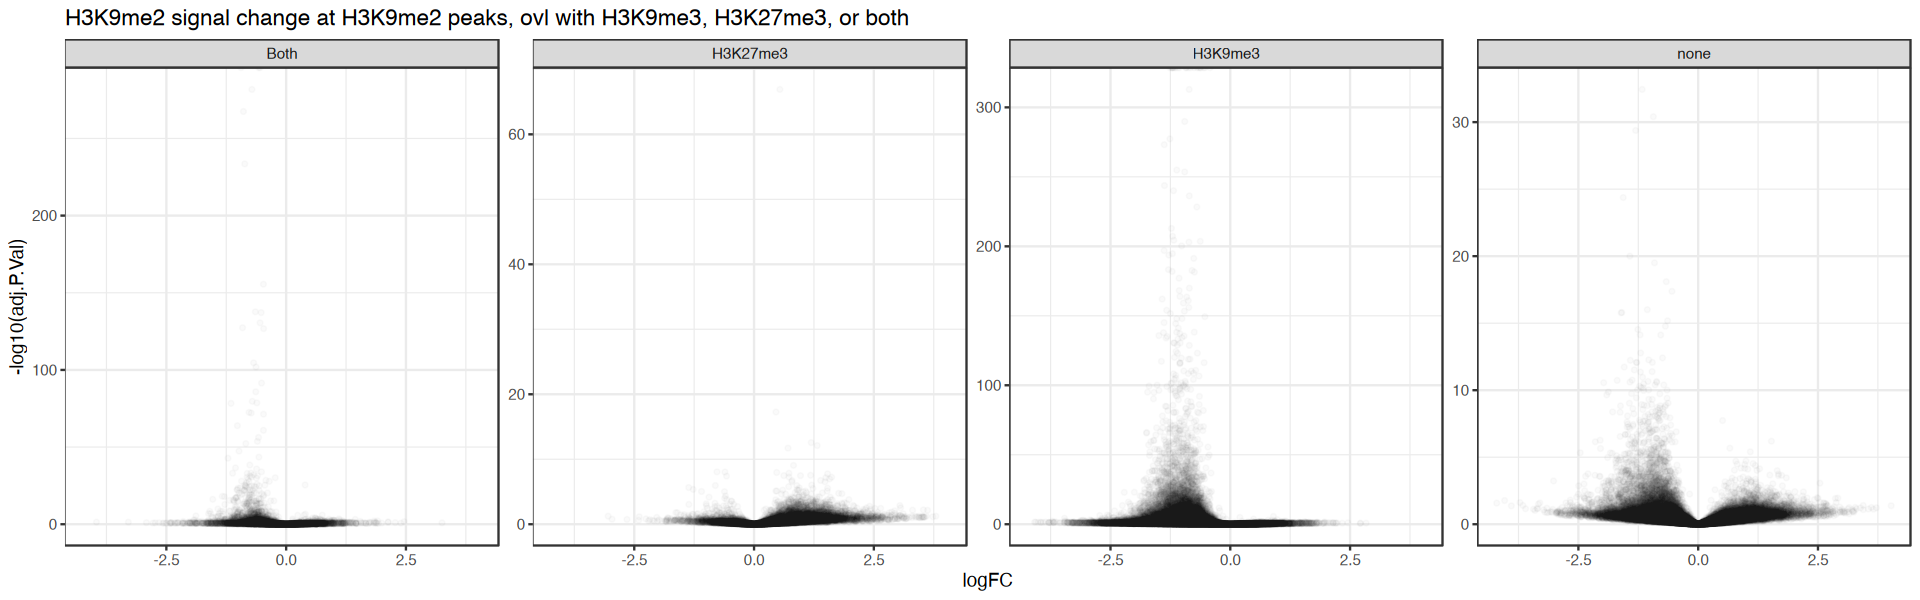

In [56]:
# overlap with different peaks
# true = overlap, false = no overlap
options(repr.plot.width=16, repr.plot.height=5)
z1 = merge(h3k9me2.k9me2peaks.dep, h3k9me2.peak.info, by.x=0, by.y="Geneid")
g1 = ggplot(z1, aes(x=logFC, y=-log10(adj.P.Val))) + geom_point(alpha=0.02, size=1) + theme_bw() + 
ggtitle("H3K9me2 signal change at H3K9me2 peaks, ovl with H3K9me3, H3K27me3, or both") + facet_wrap(vars(ovl), scales = "free_y", nrow = 1)

g1

In [54]:
table(h3k9me2.peak.info$ovl)


    Both H3K27me3  H3K9me3     none 
    8904    17541    59406    52665 

In [69]:
dim(subset(subset(z1, ovl=="none"), logFC>0 & adj.P.Val < 0.05))  # 2413/641 out of 52k
dim(subset(subset(z1, ovl=="H3K9me3"), logFC<0 & adj.P.Val < 0.05))  # 14899/61 out of 59k
dim(subset(subset(z1, ovl=="H3K27me3"), logFC>0 & adj.P.Val < 0.05))  # 80/1390 out of 17k
dim(subset(subset(z1, ovl=="Both"), logFC<0 & adj.P.Val < 0.05))  # 1286/131 out of 17k

[1] 641  15

[1] 14899    15

[1] 1390   15

[1] 1286   15

In [71]:
# where do WIZ and G9a bind?
wiz.peak.info$ovl = "none"
wiz.peaks.ovl.k9me3 = findOverlaps(wiz.peaks.gr, h3k9me3.peaks.gr, select="arbitrary")
wiz.peak.info[!is.na(wiz.peaks.ovl.k9me3),]$ovl = "H3K9me3"
wiz.peaks.ovl.k27me3 = findOverlaps(wiz.peaks.gr, h3k27me3.peaks.gr, select="arbitrary")
wiz.peak.info[!is.na(wiz.peaks.ovl.k27me3),]$ovl = "H3K27me3"
wiz.peak.info[!is.na(wiz.peaks.ovl.k27me3) & !is.na(wiz.peaks.ovl.k9me3),]$ovl = "Both"
table(wiz.peak.info$ovl)

Warning message in .merge_two_Seqinfo_objects(x, y):
“Each of the 2 combined objects has sequence levels not in the other:
  - in 'x': chrM
  - in 'y': chr14_GL000009v2_random, chr14_GL000194v1_random, chr14_KI270722v1_random, chr14_KI270723v1_random, chr14_KI270724v1_random, chr14_KI270725v1_random, chr15_KI270727v1_random, chr16_KI270728v1_random, chr17_KI270729v1_random, chr17_KI270730v1_random, chr1_KI270706v1_random, chr1_KI270707v1_random, chr1_KI270709v1_random, chr1_KI270710v1_random, chr1_KI270712v1_random, chr22_KI270731v1_random, chr22_KI270732v1_random, chr22_KI270735v1_random, chr22_KI270736v1_random, chr22_KI270737v1_random, chr22_KI270738v1_random, chr22_KI270739v1_random, chr2_KI270715v1_random, chr4_GL000008v2_random, chr5_GL000208v1_random, chr9_KI270718v1_random, chr9_KI270719v1_random, chr9_KI270720v1_random, chrEBV, chrUn_GL000213v1, chrUn_GL000216v2, chrUn_GL000218v1, chrUn_GL000224v1, chrUn_GL000226v1, chrUn_KI270302v1, chrUn_KI270304v1, chrUn_KI270305v1, chrUn_K


    Both H3K27me3  H3K9me3     none 
     164     4150     3291    21811 

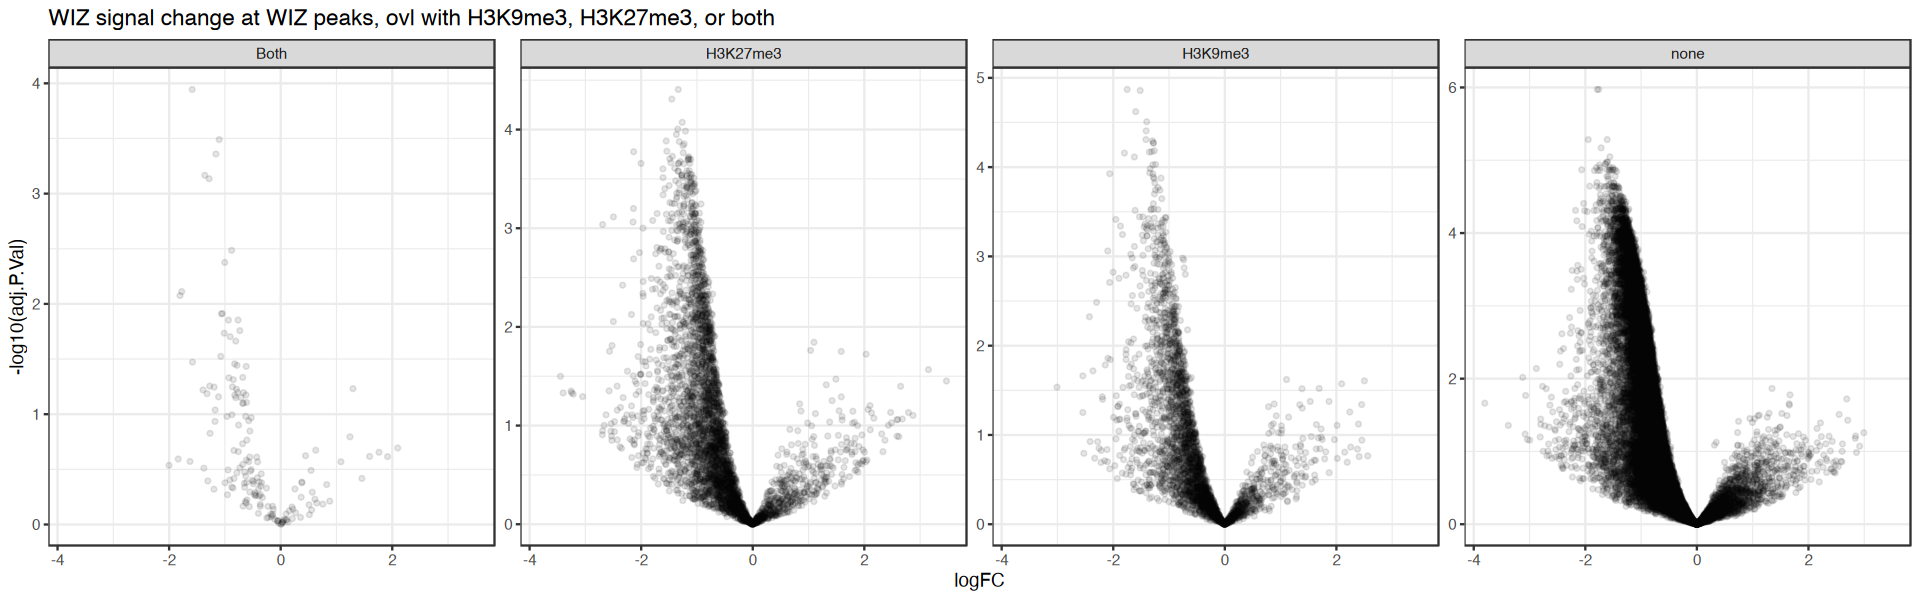

In [82]:
# overlap with different peaks
# true = overlap, false = no overlap
options(repr.plot.width=16, repr.plot.height=5)
z1 = merge(wiz.wizpeaks.dep, wiz.peak.info, by.x=0, by.y="Geneid")
g1 = ggplot(z1, aes(x=logFC, y=-log10(adj.P.Val))) + geom_point(alpha=0.1, size=1) + theme_bw() + 
ggtitle("WIZ signal change at WIZ peaks, ovl with H3K9me3, H3K27me3, or both") + facet_wrap(vars(ovl), scales = "free_y", nrow = 1)

g1

In [73]:
# where do WIZ and G9a bind?
g9a.peak.info$ovl = "none"
g9a.peaks.ovl.k9me3 = findOverlaps(g9a.peaks.gr, h3k9me3.peaks.gr, select="arbitrary")
g9a.peak.info[!is.na(g9a.peaks.ovl.k9me3),]$ovl = "H3K9me3"
g9a.peaks.ovl.k27me3 = findOverlaps(g9a.peaks.gr, h3k27me3.peaks.gr, select="arbitrary")
g9a.peak.info[!is.na(g9a.peaks.ovl.k27me3),]$ovl = "H3K27me3"
g9a.peak.info[!is.na(g9a.peaks.ovl.k27me3) & !is.na(g9a.peaks.ovl.k9me3),]$ovl = "Both"
table(g9a.peak.info$ovl)

Warning message in .merge_two_Seqinfo_objects(x, y):
“Each of the 2 combined objects has sequence levels not in the other:
  - in 'x': chrM
  - in 'y': chr11_KI270721v1_random, chr14_GL000009v2_random, chr14_GL000194v1_random, chr14_KI270722v1_random, chr14_KI270723v1_random, chr14_KI270724v1_random, chr14_KI270725v1_random, chr15_KI270727v1_random, chr16_KI270728v1_random, chr17_KI270729v1_random, chr17_KI270730v1_random, chr1_KI270706v1_random, chr1_KI270707v1_random, chr1_KI270709v1_random, chr1_KI270710v1_random, chr1_KI270712v1_random, chr1_KI270714v1_random, chr22_KI270731v1_random, chr22_KI270732v1_random, chr22_KI270736v1_random, chr22_KI270737v1_random, chr22_KI270738v1_random, chr22_KI270739v1_random, chr2_KI270716v1_random, chr3_GL000221v1_random, chr4_GL000008v2_random, chr5_GL000208v1_random, chr9_KI270718v1_random, chr9_KI270719v1_random, chr9_KI270720v1_random, chrEBV, chrUn_GL000213v1, chrUn_GL000214v1, chrUn_GL000216v2, chrUn_GL000218v1, chrUn_GL000219v1, chrUn_KI27030


    Both H3K27me3  H3K9me3     none 
      16      291      566     3370 

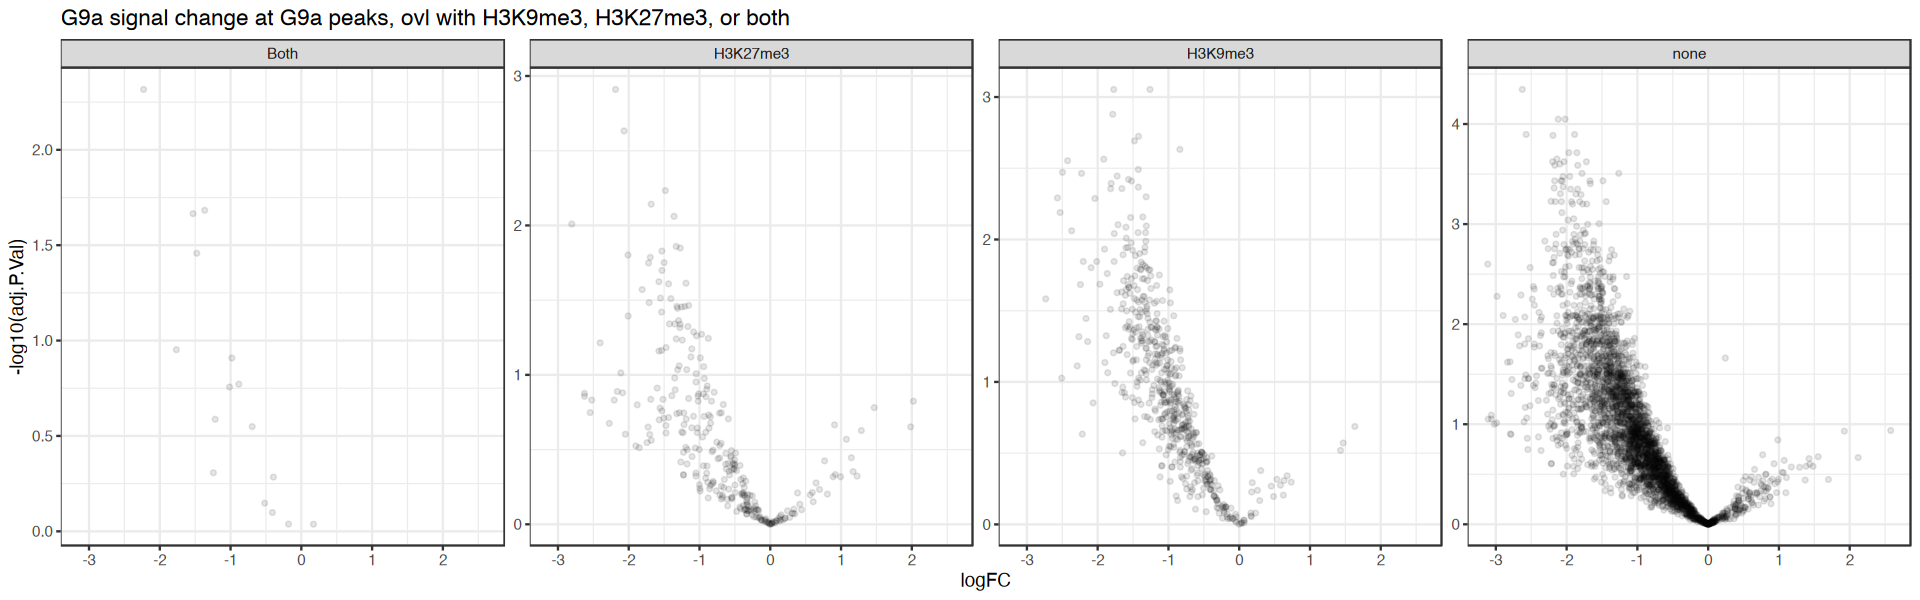

In [81]:
# overlap with different peaks
# true = overlap, false = no overlap
options(repr.plot.width=16, repr.plot.height=5)
z1 = merge(g9a.g9apeaks.dep, g9a.peak.info, by.x=0, by.y="Geneid")
g1 = ggplot(z1, aes(x=logFC, y=-log10(adj.P.Val))) + geom_point(alpha=0.1, size=1) + theme_bw() + 
ggtitle("G9a signal change at G9a peaks, ovl with H3K9me3, H3K27me3, or both") + facet_wrap(vars(ovl), scales = "free_y", nrow = 1)

g1

In [78]:
h3k9me3.peak.info$ovl = "none"
h3k9me3.peaks.ovl.k9me2 = findOverlaps(h3k9me3.peaks.gr, h3k9me2.peaks.gr, select="arbitrary")
h3k9me3.peak.info[!is.na(h3k9me3.peaks.ovl.k9me2),]$ovl = "H3K9me2"
h3k9me3.peaks.ovl.k27me3 = findOverlaps(h3k9me3.peaks.gr, h3k27me3.peaks.gr, select="arbitrary")
h3k9me3.peak.info[!is.na(h3k9me3.peaks.ovl.k27me3),]$ovl = "H3K27me3"
h3k9me3.peak.info[!is.na(h3k9me3.peaks.ovl.k27me3) & !is.na(h3k9me3.peaks.ovl.k9me2),]$ovl = "Both"
table(h3k9me3.peak.info$ovl)

Warning message in .merge_two_Seqinfo_objects(x, y):
“Each of the 2 combined objects has sequence levels not in the other:
  - in 'x': chr11_KI270721v1_random, chr14_GL000194v1_random, chr14_GL000225v1_random, chr14_KI270722v1_random, chr14_KI270723v1_random, chr14_KI270724v1_random, chr15_KI270727v1_random, chr17_KI270729v1_random, chr17_KI270730v1_random, chr1_KI270707v1_random, chr1_KI270709v1_random, chr1_KI270710v1_random, chr1_KI270712v1_random, chr1_KI270713v1_random, chr1_KI270714v1_random, chr22_KI270731v1_random, chr22_KI270732v1_random, chr22_KI270734v1_random, chr22_KI270735v1_random, chr22_KI270736v1_random, chr22_KI270737v1_random, chr22_KI270738v1_random, chr22_KI270739v1_random, chr2_KI270716v1_random, chr5_GL000208v1_random, chr9_KI270719v1_random, chr9_KI270720v1_random, chrEBV, chrUn_GL000213v1, chrUn_GL000214v1, chrUn_GL000216v2, chrUn_GL000218v1, chrUn_GL000220v1, chrUn_GL000226v1, chrUn_KI270302v1, chrUn_KI270304v1, chrUn_KI270305v1, chrUn_KI270311v1, chrUn_KI2703


    Both H3K27me3  H3K9me2     none 
    6705     5401    28863    33418 

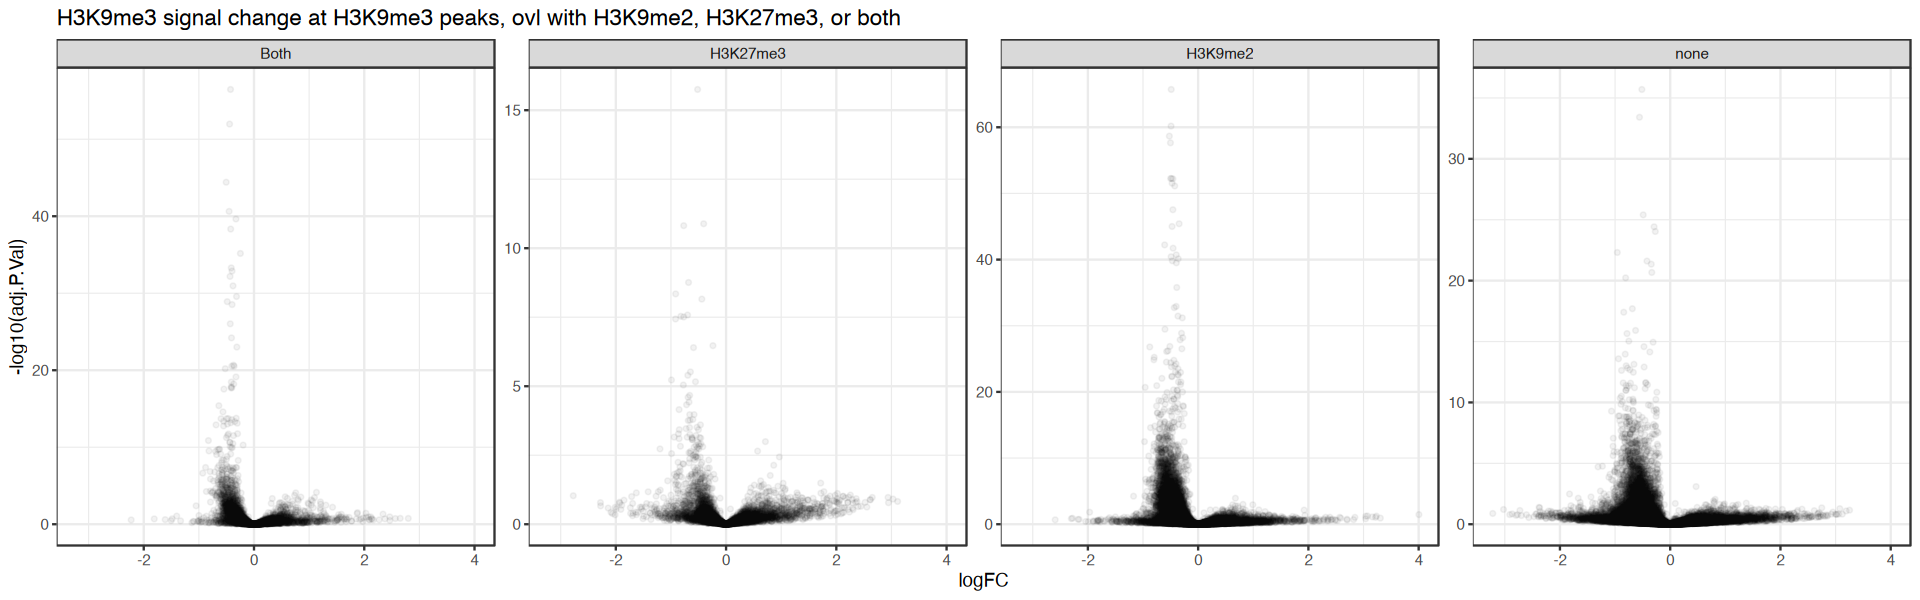

In [80]:
# overlap with different peaks
# true = overlap, false = no overlap
options(repr.plot.width=16, repr.plot.height=5)
z1 = merge(h3k9me3.k9me3peaks.dep, h3k9me3.peak.info, by.x=0, by.y="Geneid")
g1 = ggplot(z1, aes(x=logFC, y=-log10(adj.P.Val))) + geom_point(alpha=0.05, size=1) + theme_bw() + 
ggtitle("H3K9me3 signal change at H3K9me3 peaks, ovl with H3K9me2, H3K27me3, or both") + facet_wrap(vars(ovl), scales = "free_y", nrow = 1)

g1

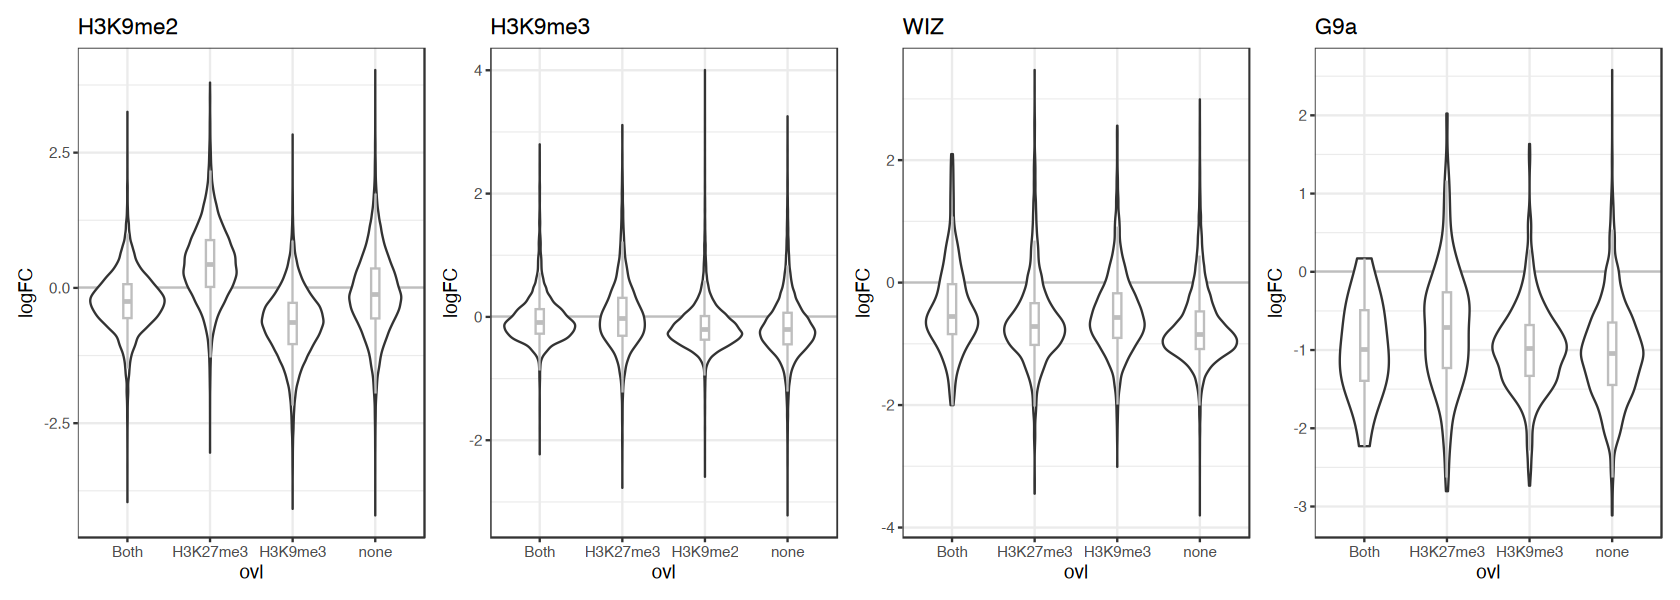

In [84]:
options(repr.plot.width=14, repr.plot.height=5)
g1 = ggplot(merge(h3k9me2.k9me2peaks.dep, h3k9me2.peak.info, by.x=0, by.y="Geneid"), aes(x=ovl, y=logFC)) + geom_hline(yintercept=0, color="gray") + geom_violin() + 
geom_boxplot(width=0.1, color="grey", alpha=0.2, outliers=F) + theme_bw() + ggtitle("H3K9me2")
g2 = ggplot(merge(h3k9me3.k9me3peaks.dep, h3k9me3.peak.info, by.x=0, by.y="Geneid"), aes(x=ovl, y=logFC)) + geom_hline(yintercept=0, color="gray") + geom_violin() + 
geom_boxplot(width=0.1, color="grey", alpha=0.2, outliers=F) + theme_bw() + ggtitle("H3K9me3")
g3 = ggplot(merge(wiz.wizpeaks.dep, wiz.peak.info, by.x=0, by.y="Geneid"), aes(x=ovl, y=logFC)) + geom_hline(yintercept=0, color="gray") + geom_violin() + 
geom_boxplot(width=0.1, color="grey", alpha=0.2, outliers=F) + theme_bw() + ggtitle("WIZ")
g4 = ggplot(merge(g9a.g9apeaks.dep, g9a.peak.info, by.x=0, by.y="Geneid"), aes(x=ovl, y=logFC)) + geom_hline(yintercept=0, color="gray") + geom_violin() + 
geom_boxplot(width=0.1, color="grey", alpha=0.2, outliers=F) + theme_bw() + ggtitle("G9a")

g1 + g2 + g3 + g4 + plot_layout(nrow=1)
ggsave("250809_peak_logfc_overlap_k27me3.pdf", width=9, height=3)

## H3K27me3 changes

In [87]:
subset(h3k27me3.peak.info, Geneid=="h3k27me3_peak48393")

,Geneid,Chr,Start,End,Strand,Length
,<chr>,<chr>,<int>,<int>,<chr>,<int>
48393,h3k27me3_peak48393,chrX,125200876,125205070,+,4195


In [85]:
subset(h3k27me3.h3k27me3peaks.dep, logFC < -1 & adj.P.Val < 0.05)

,logFC,AveExpr,t,P.Value,adj.P.Val,B
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
h3k27me3_peak43268,-1.025490,2.8847181,-6.416134,1.402024e-10,2.729646e-08,12.28009205
h3k27me3_peak48393,-1.147520,2.5704517,-6.299466,2.995155e-10,5.421009e-08,11.09818116
h3k27me3_peak25088,-1.073013,2.7044324,-6.238084,4.441653e-10,7.536622e-08,11.02128377
h3k27me3_peak16866,-1.009289,2.5379844,-5.581412,2.389943e-08,2.678709e-06,7.55466146
h3k27me3_peak6297,-1.369851,1.8476252,-5.491224,3.998187e-08,4.174859e-06,5.78096686
h3k27me3_peak21036,-1.184237,1.8027582,-4.786326,1.700272e-06,1.142901e-04,3.16067567
h3k27me3_peak3143,-1.115501,1.8589380,-4.662637,3.124580e-06,1.888570e-04,2.84622977
h3k27me3_peak2131,-1.147036,1.6511357,-4.397470,1.095972e-05,5.442880e-04,1.68263022
h3k27me3_peak41639,-1.067028,1.7808457,-4.331991,1.478653e-05,6.981527e-04,1.65109250


## H3K9me2 and H3K9me3 peaks

### H3K27me3

In [56]:
subset(h3k9me2.peak.info, Geneid=="h3k9me2_peak118121")

,Geneid,Chr,Start,End,Strand,Length
,<chr>,<chr>,<int>,<int>,<chr>,<int>
118121,h3k9me2_peak118121,chr7,104092385,104095837,+,3453


In [57]:
head(h3k27me3.h3k9me2peaks.dep)

,logFC,AveExpr,t,P.Value,adj.P.Val,B
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
h3k9me2_peak128429,-0.3815889,5.317821,-17.596588,2.530268e-10,3.504826e-05,13.541128
h3k9me2_peak80793,-0.2276356,6.092674,-11.111105,6.309341e-08,2.330495e-03,6.516838
h3k9me2_peak128443,-0.4221501,4.910504,-11.062066,6.642548e-08,2.330495e-03,7.993573
h3k9me2_peak129042,-0.3079134,5.848437,-11.049646,6.729893e-08,2.330495e-03,6.829162
h3k9me2_peak128439,-0.3168488,5.667301,-10.326377,1.471546e-07,4.076653e-03,6.280093
h3k9me2_peak64802,-0.2896841,6.030659,-9.566646,3.514381e-07,8.113301e-03,4.768823


In [60]:
subset(h3k9me3.peak.info, Geneid=="h3k9me3_peak21046")

,Geneid,Chr,Start,End,Strand,Length
,<chr>,<chr>,<int>,<int>,<chr>,<int>
21046,h3k9me3_peak21046,chr14_GL000225v1_random,53,210485,+,210433


In [58]:
head(h3k27me3.h3k9me3peaks.dep)

,logFC,AveExpr,t,P.Value,adj.P.Val,B
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
h3k9me3_peak22655,-0.2339226,7.842211,-17.13456,3.757287e-09,0.0002794933,7.911200
h3k9me3_peak65218,-0.5281883,6.335472,-14.83412,1.671374e-08,0.0004708455,9.074712
h3k9me3_peak46731,0.4433353,5.502050,14.65125,1.898902e-08,0.0004708455,9.475349
h3k9me3_peak69544,0.6866719,5.486780,13.24089,5.350545e-08,0.0009950275,8.374234
h3k9me3_peak21046,0.7456061,4.984702,12.77381,7.707552e-08,0.0011466833,8.263199
h3k9me3_peak54787,-0.6859869,4.222047,-10.86396,3.918201e-07,0.0048577202,6.918358


### H3K9me2 proximity to G9a and WIZ

In [118]:
k9me2.prox.wiz = read.table("../results/h3k9me2_peaks_dist_wiz.bed")
h3k9me2.peak.info$wiz_dist = k9me2.prox.wiz$V7
head(h3k9me2.peak.info)

,Geneid,Chr,Start,End,Strand,Length,wiz_dist
,<chr>,<chr>,<int>,<int>,<chr>,<int>,<int>
1,h3k9me2_peak1,chr1,883745,885088,+,1344,13551
2,h3k9me2_peak2,chr1,1382377,1382668,+,292,6421
3,h3k9me2_peak3,chr1,2064730,2065153,+,424,19152
4,h3k9me2_peak4,chr1,2154664,2155041,+,378,20616
5,h3k9me2_peak5,chr1,2617917,2618186,+,270,24458
6,h3k9me2_peak6,chr1,2653752,2655431,+,1680,10083


Warning message:
“Removed 67 rows containing non-finite outside the scale range (`stat_bin()`).”


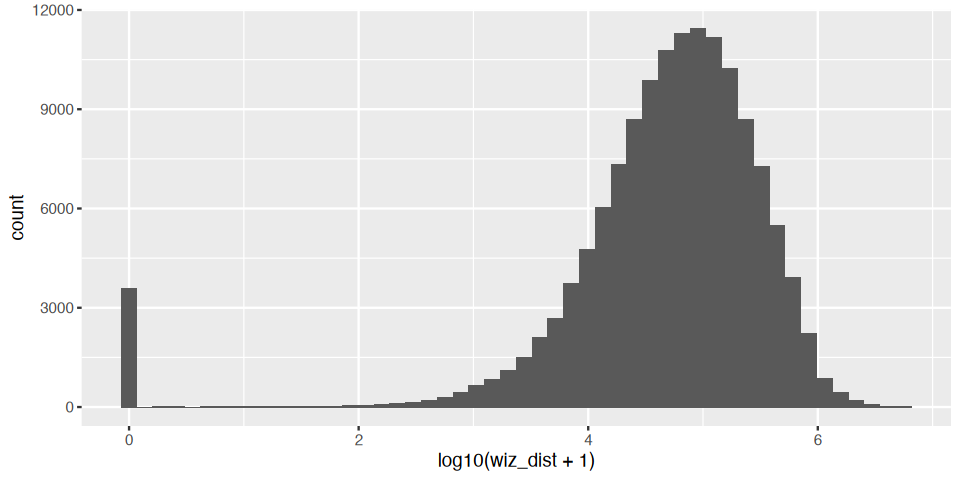

In [125]:
options(repr.plot.width=8, repr.plot.height=4)
ggplot(h3k9me2.peak.info, aes(x=log10(wiz_dist+1))) + geom_histogram(bins=50)

In [191]:
k9me2.prox.g9a = read.table("../results/h3k9me2_peaks_dist_g9a.bed")
h3k9me2.peak.info$g9a_dist = k9me2.prox.g9a$V7
head(h3k9me2.peak.info)

,Geneid,Chr,Start,End,Strand,Length,wiz_dist,g9a_dist
,<chr>,<chr>,<int>,<int>,<chr>,<int>,<int>,<int>
1,h3k9me2_peak1,chr1,883745,885088,+,1344,13551,486689
2,h3k9me2_peak2,chr1,1382377,1382668,+,292,6421,10172
3,h3k9me2_peak3,chr1,2064730,2065153,+,424,19152,145062
4,h3k9me2_peak4,chr1,2154664,2155041,+,378,20616,234996
5,h3k9me2_peak5,chr1,2617917,2618186,+,270,24458,698249
6,h3k9me2_peak6,chr1,2653752,2655431,+,1680,10083,734084


Warning message:
“Removed 98 rows containing non-finite outside the scale range (`stat_bin()`).”


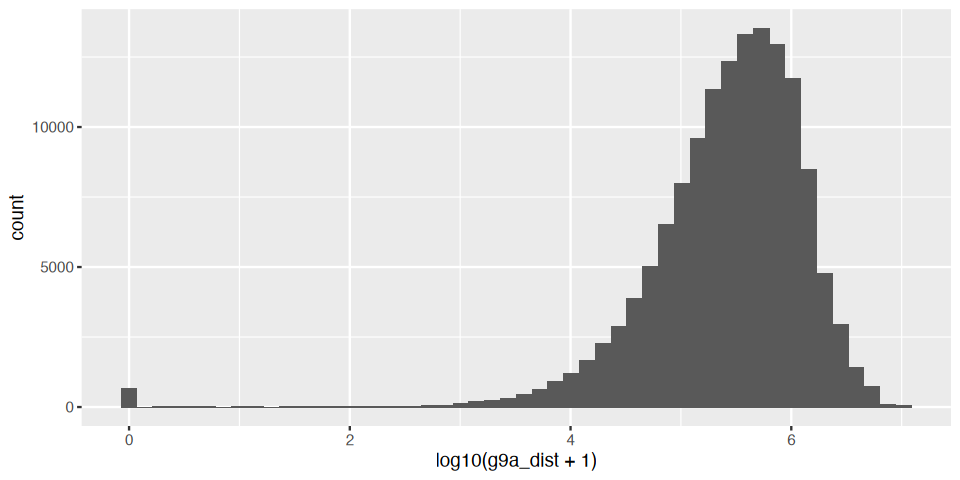

In [192]:
options(repr.plot.width=8, repr.plot.height=4)
ggplot(h3k9me2.peak.info, aes(x=log10(g9a_dist+1))) + geom_histogram(bins=50)

Warning message:
“Removed 3 rows containing non-finite outside the scale range (`stat_bin()`).”


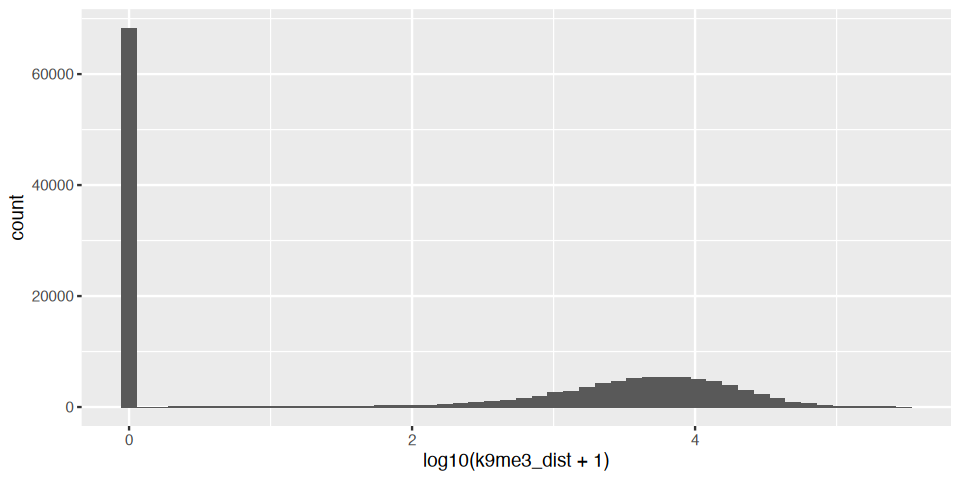

In [212]:
k9me2.prox.k9me3 = read.table("../results/h3k9me2_peaks_dist_h3k9me3.bed")
h3k9me2.peak.info$k9me3_dist = k9me2.prox.k9me3$V7
options(repr.plot.width=8, repr.plot.height=4)
ggplot(h3k9me2.peak.info, aes(x=log10(k9me3_dist+1))) + geom_histogram(bins=50)

In [215]:
h3k9me2.k9me2peaks.dep.prox = merge(h3k9me2.k9me2peaks.dep, h3k9me2.peak.info[,c("Geneid", "wiz_dist")], by.x=0, by.y="Geneid")
h3k9me2.k9me2peaks.dep.prox = merge(h3k9me2.k9me2peaks.dep.prox, h3k9me2.peak.info[,c("Geneid", "g9a_dist")], by.x="Row.names", by.y="Geneid")
h3k9me2.k9me2peaks.dep.prox = merge(h3k9me2.k9me2peaks.dep.prox, h3k9me2.peak.info[,c("Geneid", "k9me3_dist")], by.x="Row.names", by.y="Geneid")

In [216]:
head(h3k9me2.k9me2peaks.dep.prox)

,Row.names,logFC,AveExpr,t,P.Value,adj.P.Val,B,wiz_dist,g9a_dist,k9me3_dist
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>
1,h3k9me2_peak1,-0.3424152,0.18689344,-0.8572782,0.3912915479,0.598797327,-5.2865737,13551,486689,12757
2,h3k9me2_peak10,-0.8473351,0.03384194,-1.9544834,0.0506445841,0.182636949,-3.9165261,151589,875590,0
3,h3k9me2_peak100,0.8395150,-2.06115548,0.8282596,0.4075238655,0.612646212,-4.7727749,541131,702008,13452
4,h3k9me2_peak1000,-0.9549309,1.19858039,-3.3481434,0.0008136033,0.008454394,-0.7087797,31297,31760,0
5,h3k9me2_peak10000,0.3542419,0.79600873,1.1473523,0.2512365548,0.465756788,-5.2322613,87713,134437,0
6,h3k9me2_peak100000,-0.2563372,-0.41574694,-0.5050593,0.6135173740,0.769694506,-5.3026371,261802,533649,0


In [219]:
h3k9me2.k9me2peaks.dep.prox <- h3k9me2.k9me2peaks.dep.prox %>%
  mutate(wiz_bin = cut(wiz_dist,
                     breaks = c(-1,100,1000,10000,100000,1e8), # Creates 10 bins
                     include.lowest = TRUE,
                     right = TRUE # Makes bins like [min, val1), [val1, val2), etc.
                     ),
         g9a_bin = cut(g9a_dist,
                     breaks = c(-1,100,1000,10000,100000,1e8), # Creates 10 bins
                     include.lowest = TRUE,
                     right = TRUE # Makes bins like [min, val1), [val1, val2), etc.
                     ),
         k9me3_bin = cut(k9me3_dist,
                     breaks = c(-1,100,1000,10000,1e8), # Creates 10 bins
                     include.lowest = TRUE,
                     right = TRUE # Makes bins like [min, val1), [val1, val2), etc.
                     )
         )

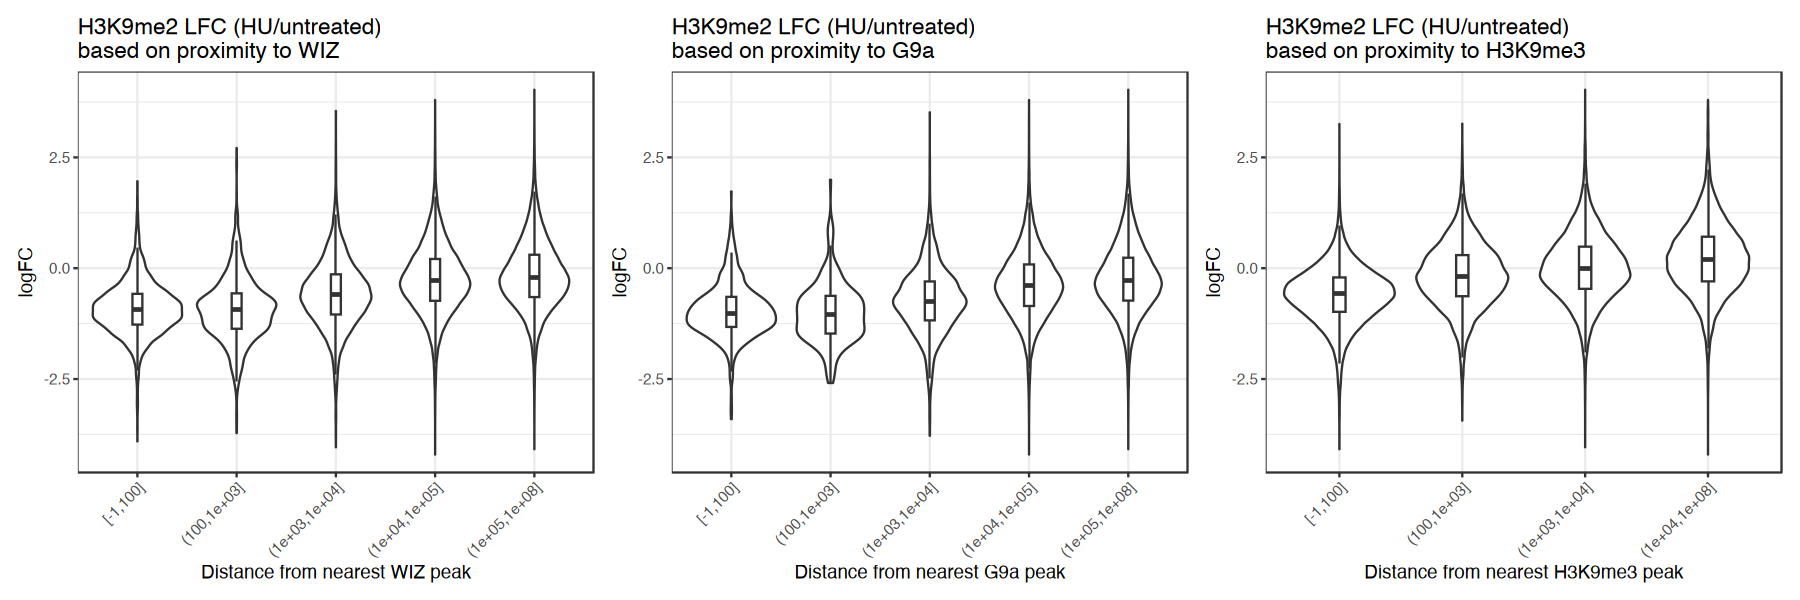

In [229]:
options(repr.plot.width=15, repr.plot.height=5)
g1 = ggplot(h3k9me2.k9me2peaks.dep.prox, aes(x=wiz_bin, y=logFC)) + geom_violin() +  
  geom_boxplot(width=.1, outliers=F) + theme_bw() + 
  ggtitle("H3K9me2 LFC (HU/untreated)\nbased on proximity to WIZ") +
  xlab("Distance from nearest WIZ peak") +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust=1))
g2 = ggplot(h3k9me2.k9me2peaks.dep.prox, aes(x=g9a_bin, y=logFC)) + geom_violin() +  
  geom_boxplot(width=.1, outliers=F) + theme_bw() + 
  ggtitle("H3K9me2 LFC (HU/untreated)\nbased on proximity to G9a") +
  xlab("Distance from nearest G9a peak") +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust=1))
g3 = ggplot(h3k9me2.k9me2peaks.dep.prox, aes(x=k9me3_bin, y=logFC)) + geom_violin() +  
  geom_boxplot(width=.1, outliers=F) + theme_bw() + 
  ggtitle("H3K9me2 LFC (HU/untreated)\nbased on proximity to H3K9me3") +
  xlab("Distance from nearest H3K9me3 peak") +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust=1))
g1 + g2 + g3

ggsave("../results/250604_h3k9me2_lfc_prox_to_wiz_g9a_k9me3.pdf", width=12, height=6)

### H3K9me3 proximity

In [231]:
k9me3.prox.wiz = read.table("../results/h3k9me3_peaks_dist_wiz.bed")
h3k9me3.peak.info$wiz_dist = k9me3.prox.wiz$V7
head(h3k9me3.peak.info)

k9me3.prox.g9a = read.table("../results/h3k9me3_peaks_dist_g9a.bed")
h3k9me3.peak.info$g9a_dist = k9me3.prox.g9a$V7
head(h3k9me3.peak.info)

k9me3.prox.k9me2 = read.table("../results/h3k9me3_peaks_dist_h3k9me2.bed")
h3k9me3.peak.info$k9me2_dist = k9me3.prox.k9me2$V7
head(h3k9me3.peak.info)

,Geneid,Chr,Start,End,Strand,Length,wiz_dist,g9a_dist
,<chr>,<chr>,<int>,<int>,<chr>,<int>,<int>,<int>
1,h3k9me3_peak1,chr1,799408,800782,+,1375,25972,570995
2,h3k9me3_peak2,chr1,812232,813295,+,1064,13459,558482
3,h3k9me3_peak3,chr1,850876,851076,+,201,18534,520701
4,h3k9me3_peak4,chr1,897844,898570,+,727,5738,473207
5,h3k9me3_peak5,chr1,969724,970105,+,382,2293,401672
6,h3k9me3_peak6,chr1,991633,993171,+,1539,4790,378606


,Geneid,Chr,Start,End,Strand,Length,wiz_dist,g9a_dist
,<chr>,<chr>,<int>,<int>,<chr>,<int>,<int>,<int>
1,h3k9me3_peak1,chr1,799408,800782,+,1375,25972,570995
2,h3k9me3_peak2,chr1,812232,813295,+,1064,13459,558482
3,h3k9me3_peak3,chr1,850876,851076,+,201,18534,520701
4,h3k9me3_peak4,chr1,897844,898570,+,727,5738,473207
5,h3k9me3_peak5,chr1,969724,970105,+,382,2293,401672
6,h3k9me3_peak6,chr1,991633,993171,+,1539,4790,378606


,Geneid,Chr,Start,End,Strand,Length,wiz_dist,g9a_dist,k9me2_dist
,<chr>,<chr>,<int>,<int>,<chr>,<int>,<int>,<int>,<int>
1,h3k9me3_peak1,chr1,799408,800782,+,1375,25972,570995,82964
2,h3k9me3_peak2,chr1,812232,813295,+,1064,13459,558482,70451
3,h3k9me3_peak3,chr1,850876,851076,+,201,18534,520701,32670
4,h3k9me3_peak4,chr1,897844,898570,+,727,5738,473207,12757
5,h3k9me3_peak5,chr1,969724,970105,+,382,2293,401672,84637
6,h3k9me3_peak6,chr1,991633,993171,+,1539,4790,378606,106546


In [232]:
h3k9me3.k9me3peaks.dep.prox = merge(h3k9me3.k9me3peaks.dep, h3k9me3.peak.info[,c("Geneid", "wiz_dist")], by.x=0, by.y="Geneid")
h3k9me3.k9me3peaks.dep.prox = merge(h3k9me3.k9me3peaks.dep.prox, h3k9me3.peak.info[,c("Geneid", "g9a_dist")], by.x="Row.names", by.y="Geneid")
h3k9me3.k9me3peaks.dep.prox = merge(h3k9me3.k9me3peaks.dep.prox, h3k9me3.peak.info[,c("Geneid", "k9me2_dist")], by.x="Row.names", by.y="Geneid")

In [233]:
h3k9me3.k9me3peaks.dep.prox <- h3k9me3.k9me3peaks.dep.prox %>%
  mutate(wiz_bin = cut(wiz_dist,
                     breaks = c(-1,100,1000,10000,100000,1e8), # Creates 10 bins
                     include.lowest = TRUE,
                     right = TRUE # Makes bins like [min, val1), [val1, val2), etc.
                     ),
         g9a_bin = cut(g9a_dist,
                     breaks = c(-1,100,1000,10000,100000,1e8), # Creates 10 bins
                     include.lowest = TRUE,
                     right = TRUE # Makes bins like [min, val1), [val1, val2), etc.
                     ),
         k9me2_bin = cut(k9me2_dist,
                     breaks = c(-1,100,1000,10000,100000,1e8), # Creates 10 bins
                     include.lowest = TRUE,
                     right = TRUE # Makes bins like [min, val1), [val1, val2), etc.
                     ),
         )

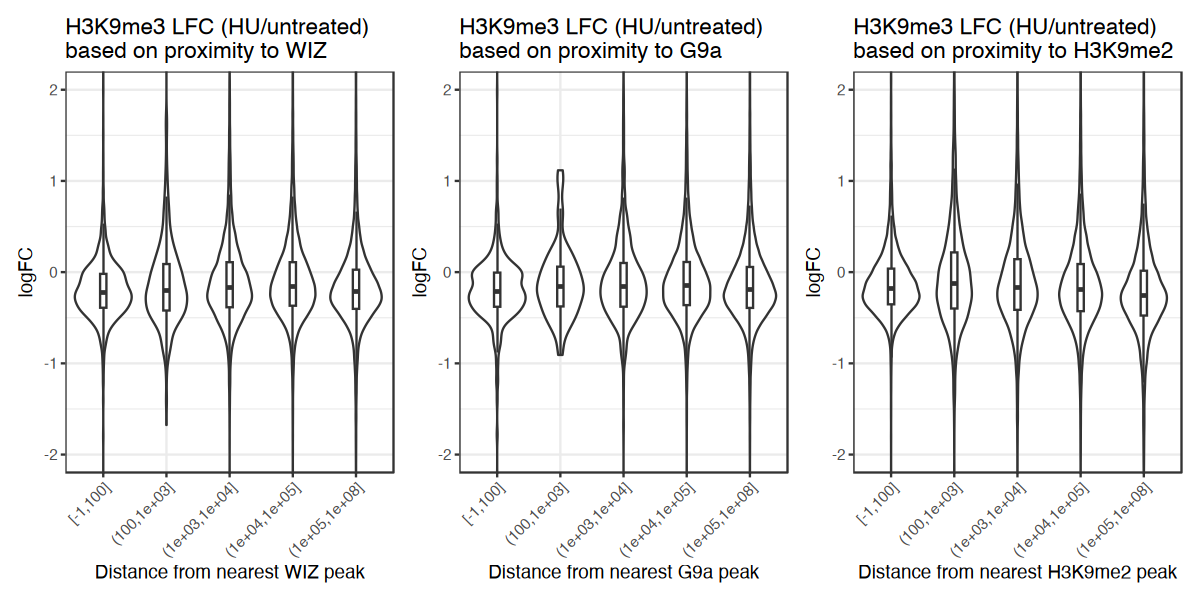

In [236]:
options(repr.plot.width=10, repr.plot.height=5)
g1 = ggplot(h3k9me3.k9me3peaks.dep.prox, aes(x=wiz_bin, y=logFC)) + geom_violin() +  
  geom_boxplot(width=.1, outliers=F) + theme_bw() + 
ggtitle("H3K9me3 LFC (HU/untreated)\nbased on proximity to WIZ") +
  xlab("Distance from nearest WIZ peak") + coord_cartesian(ylim=c(-2,2)) +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust=1))
g2 = ggplot(h3k9me3.k9me3peaks.dep.prox, aes(x=g9a_bin, y=logFC)) + geom_violin() +  
  geom_boxplot(width=.1, outliers=F) + theme_bw() + 
ggtitle("H3K9me3 LFC (HU/untreated)\nbased on proximity to G9a") +
  xlab("Distance from nearest G9a peak") + coord_cartesian(ylim=c(-2,2)) +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust=1))
g3 = ggplot(h3k9me3.k9me3peaks.dep.prox, aes(x=k9me2_bin, y=logFC)) + geom_violin() +  
  geom_boxplot(width=.1, outliers=F) + theme_bw() + 
ggtitle("H3K9me3 LFC (HU/untreated)\nbased on proximity to H3K9me2") +
  xlab("Distance from nearest H3K9me2 peak") + coord_cartesian(ylim=c(-2,2)) +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust=1))
g1 + g2 + g3
ggsave("../results/250604_h3k9me3_lfc_prox_to_wiz_g9a_k9me2.pdf", width=12, height=6)

## GREAT

In [54]:
is_file_subset <- function(file_a_path, file_b_path) {
  # 1. Read the lines from both files
  # Use tryCatch for robust error handling in case files don't exist
  tryCatch({
    lines_a <- readLines(file_a_path, warn = FALSE)
    lines_b <- readLines(file_b_path, warn = FALSE)
  }, error = function(e) {
    cat(paste("Error reading files:", e$message, "\n"))
    return(NA) # Return NA on file reading error
  })

  # Handle case where lines_a is empty (an empty file is always a subset)
  if (length(lines_a) == 0) {
    return(TRUE)
  }

  # 2. Perform the subset check
  # The %in% operator checks if each element of the left vector (lines_a)
  # is present in the right vector (lines_b).
  # The all() function then confirms that ALL results were TRUE.
  result <- all(lines_a %in% lines_b)

  return(result)
}

In [55]:
getwd()

[1] "/Users/briando/MIT Dropbox/Brian Do/MVH_Lab/Replication stress/Data/BD524/code"

In [56]:
is_file_subset("../results//250809_k9me2_down_atac.bed", "../results/unt_atac_peaks_merged.bed")

[1] TRUE